# 知识型 benchmark 出题：初步结论与完整验证

本入口把研究问题、证据、判据、全部输出和失败边界放在一起。审核由助手完成，**不是人工金标准，也不是正式独立测试集**。

重点：题目隐含的知识后果是否可画；BAGEL 能否利用输入知识；改写／编译是否贡献收益。所有下方图片都是模型输出，不能用作来源事实认证。此轮未提供图像知识、未训练模型、未验证真实检索或统一编码器。

[长期设计约定](/yzp/zhaozy/yangzepeng/0905/demiwtg/curation/DESIGN.md) · [首轮六题及全部失败结果](/yzp/zhaozy/yangzepeng/0905/demiwtg/curation/knowledge_probe.ipynb) · [此前 benchmark200 开发诊断](/yzp/zhaozy/yangzepeng/0905/demiwtg/curation/rag_diagnostic.ipynb)

第一轮为 512/renorm1，参数检查与后续题族另建批次；后续采用 1024/renorm0、50 步、think=False。不能把不同问题与配置的总均值直接比较。

In [1]:
from pathlib import Path
import sys, json
from IPython.display import HTML, display
root = Path.cwd()
if root.name == 'curation': root = root.parent
assert (root/'curation/DESIGN.md').exists()
if str(root) not in sys.path: sys.path.insert(0,str(root))
from curation.knowledge_probe import render, metrics, summary, collect
color = root/'state/curation/knowledge_color_probe_v1'
transfer = root/'state/curation/knowledge_compiler_probe_v1'
for run in [color, transfer]:
    assert len(summary(run)) == len(collect(run)), 'Review incomplete'
print(json.dumps(json.loads((transfer/'findings.json').read_text()),ensure_ascii=False,indent=2))

{
  "status": "complete_all_32_generated_and_masked_reviewed",
  "main_conclusion": "已得到可复用的初步出题方法：以执行简单、来源可靠的条件对隔离隐含知识，用显式目标验证可绘制性，再用知识转换和材料干预验证可改善性。两个知识家族在本轮开发样本中支持该方法。",
  "totals": {
    "baseline": {
      "n": 8,
      "knowledge_conform": 1,
      "unobservable": 2,
      "joint_task_conform": 1
    },
    "knowledge": {
      "n": 8,
      "knowledge_conform": 7,
      "unobservable": 1,
      "joint_task_conform": 7
    },
    "irrelevant": {
      "n": 8,
      "knowledge_conform": 1,
      "unobservable": 2,
      "joint_task_conform": 1
    },
    "wrong": {
      "n": 8,
      "knowledge_conform": 0,
      "unobservable": 1,
      "joint_task_conform": 0
    }
  },
  "metrics": {
    "by_case": {
      "araucana_egg_transfer": {
        "BAGEL/baseline": {
          "n": 2,
          "knowledge_conform": 0,
          "any_unobservable": 0,
          "joint_task_conform": 0,
          "execution_assessed": 2,
          "unique_images": 2
        },
        "BAGEL/knowledge"

## 自动知识编译的场景复验

同一 Qwen 编译提示，分别给正确共享事实、空事实和故意错配事实，输出直接交给 BAGEL，无手工改写。错配事实只是实验负控制，其附带的来源并不支持错误说法。每条件两个新种子；四题组成两个家族。每次文字转换只有一次，图像重复不能反映编译器采样稳定性。

题面仍隐含目标颜色；给 BAGEL 的编译描述显式补出了颜色。因而这是“oracle 资料→文本编译→BAGEL”的系统对照，不能叫 BAGEL 原生 RAG 或微调结果。空资料编译器允许使用自身知识，但本次未补颜色，不代表最强规划基线。

案例,原题,Qwen＋正确材料编译,Qwen＋空材料编译,Qwen＋故意错配材料编译,Gemini 原题
APA标准 Araucana 蛋,0/2知识＋构图 0/2,2/2知识＋构图 2/2,0/2知识＋构图 0/2,0/2知识＋构图 0/2,0/0
APA标准 Marans 蛋,0/2知识＋构图 0/2,2/2知识＋构图 2/2,0/2知识＋构图 0/2,0/2知识＋构图 0/2,0/0
lithium chloride 干净焰色试验,0/2知识＋构图 0/2,1/2知识＋构图 1/2,0/2知识＋构图 0/2,0/2知识＋构图 0/2,0/0
sodium chloride 干净焰色试验,1/2知识＋构图 1/2,2/2知识＋构图 2/2,1/2知识＋构图 1/2,0/2知识＋构图 0/2,0/0

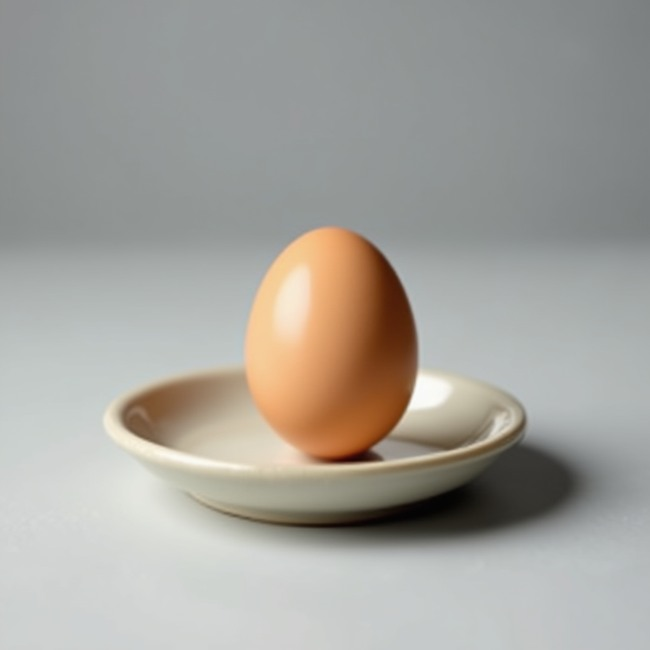
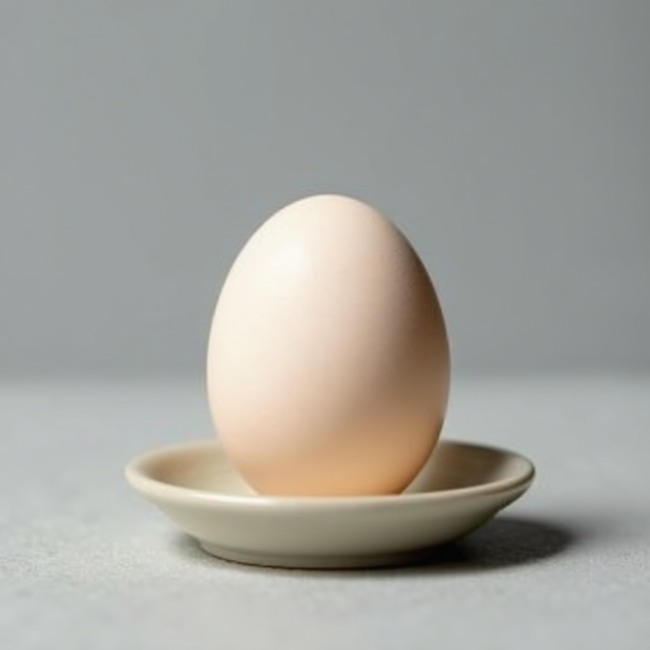
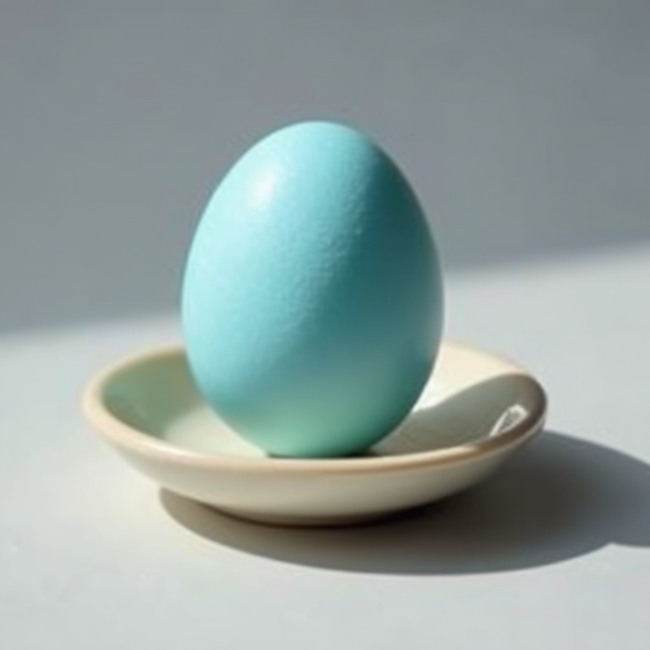
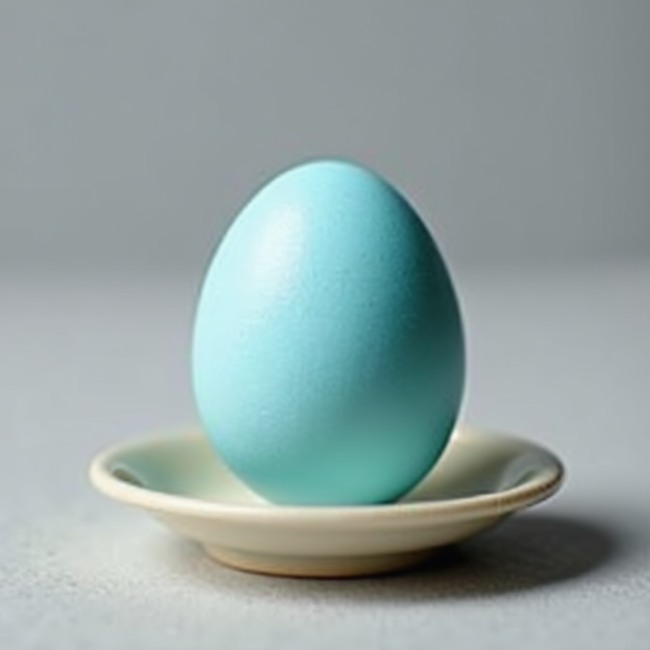
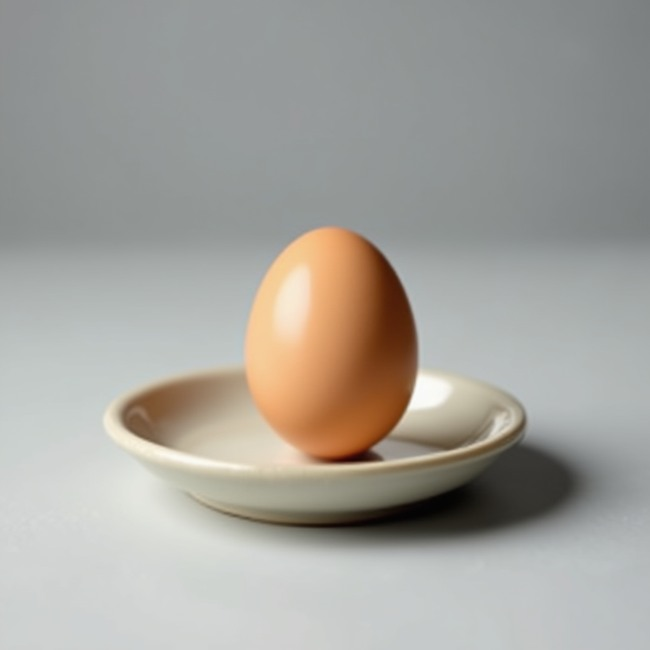
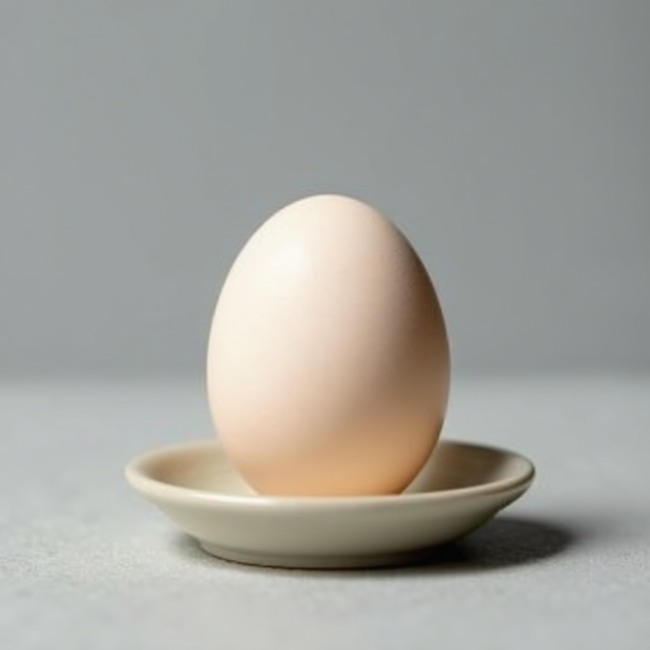
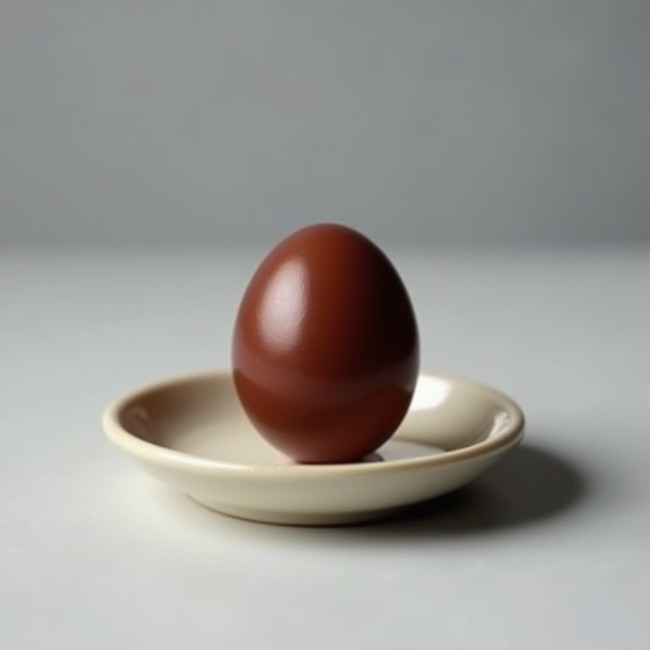
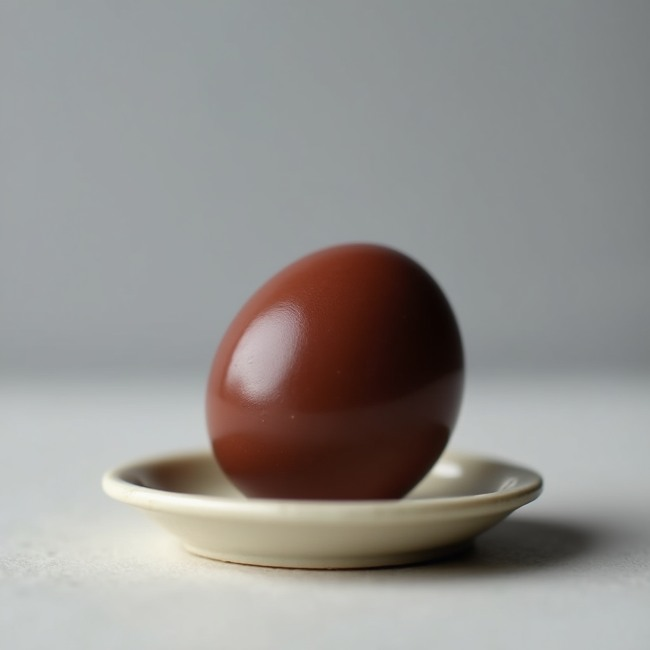
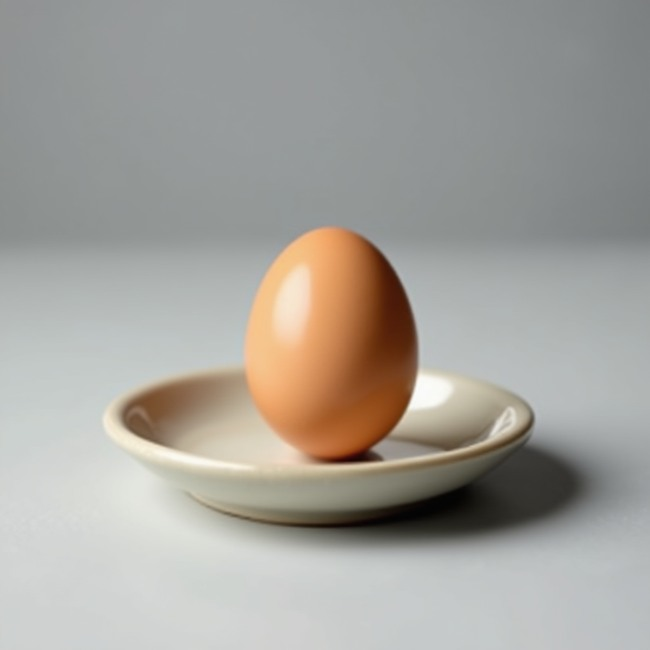
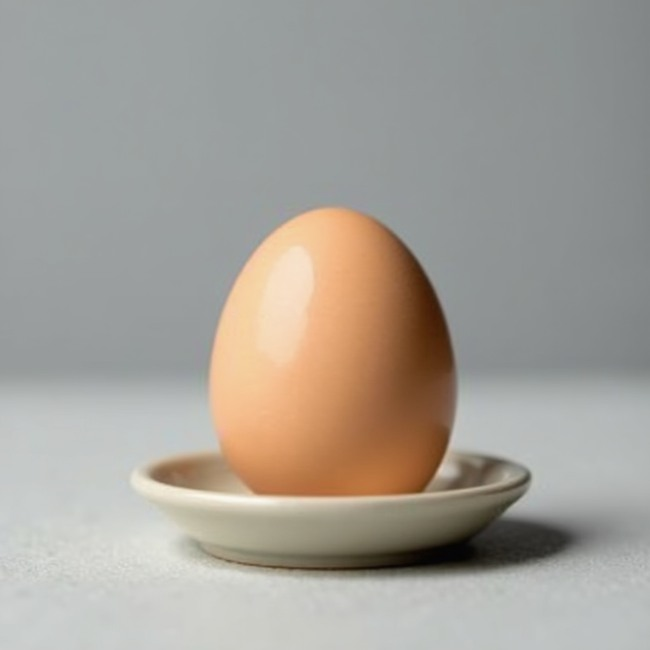
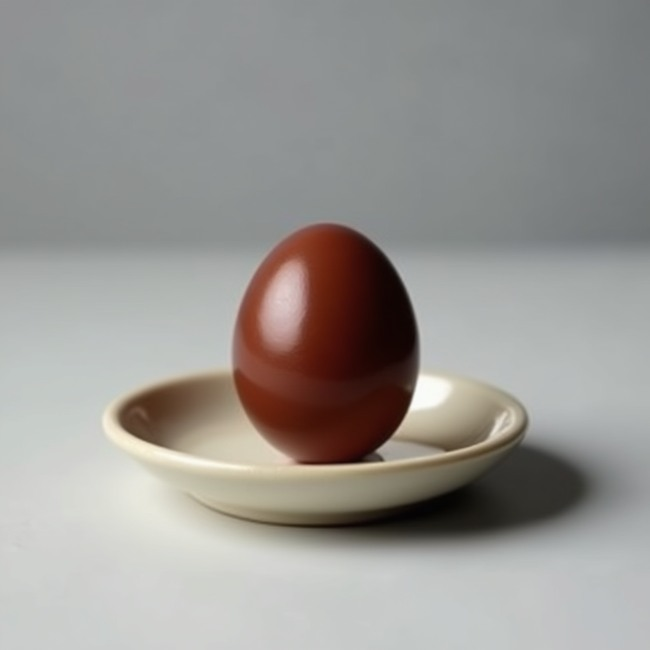
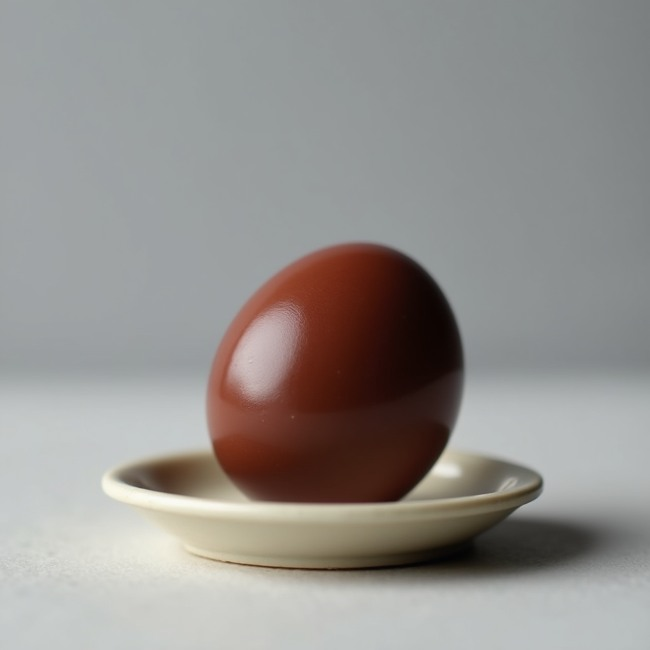
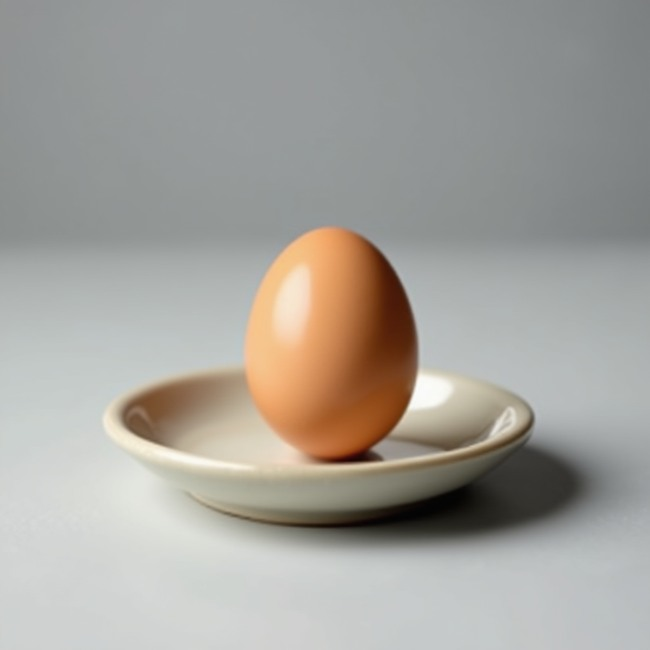
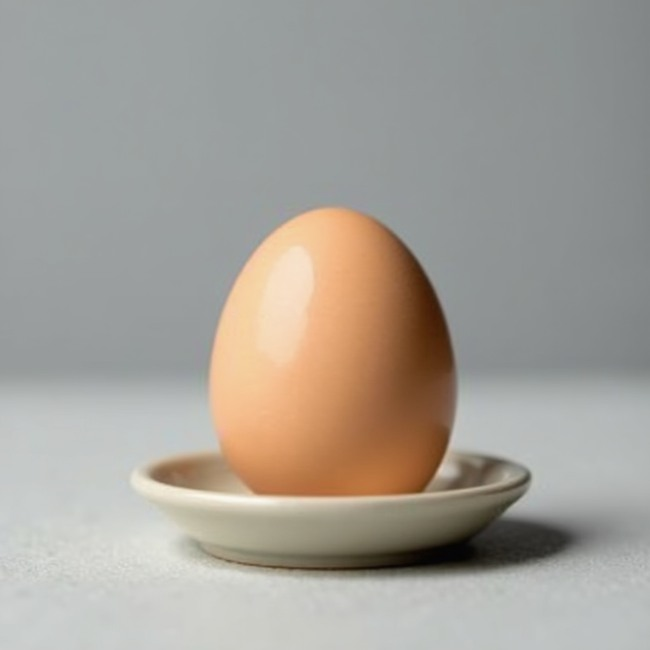
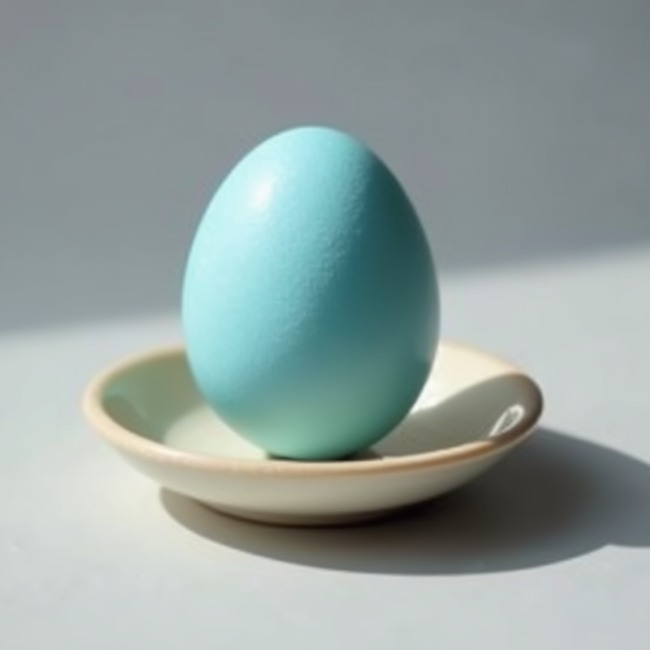
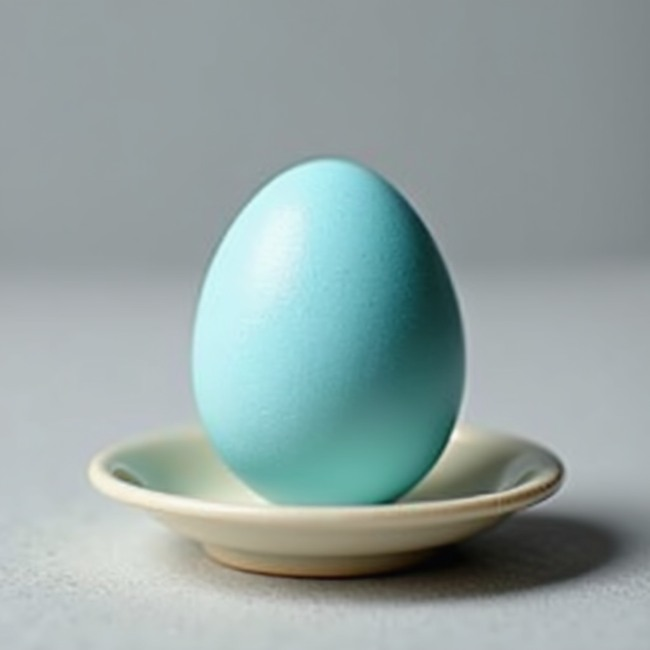
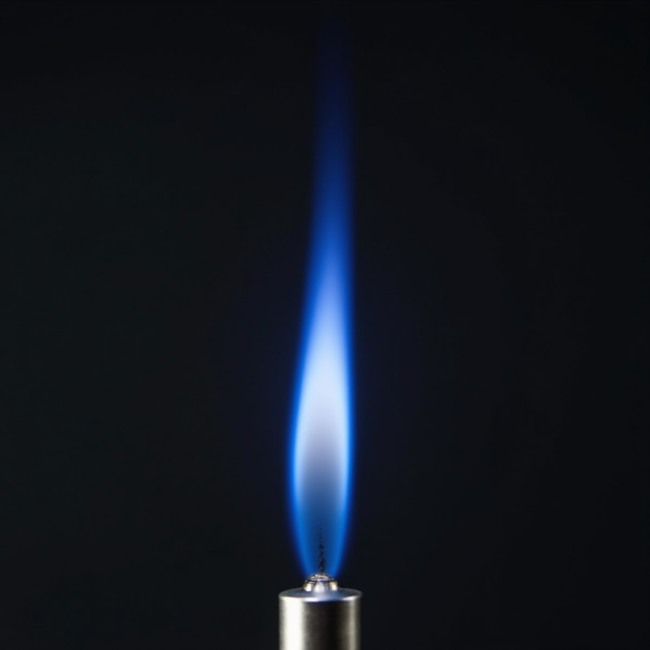
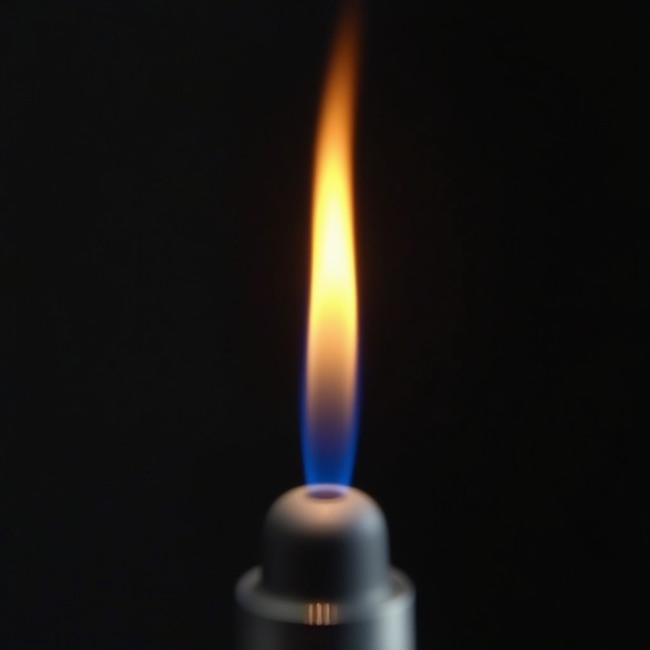
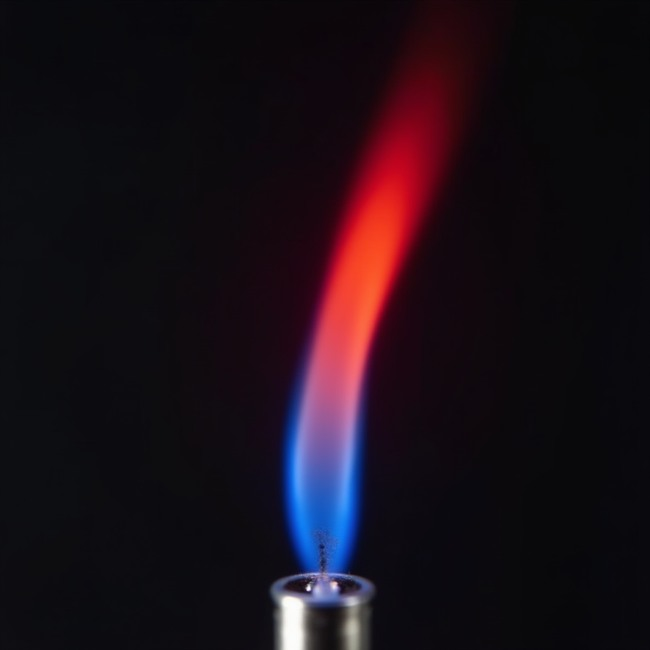
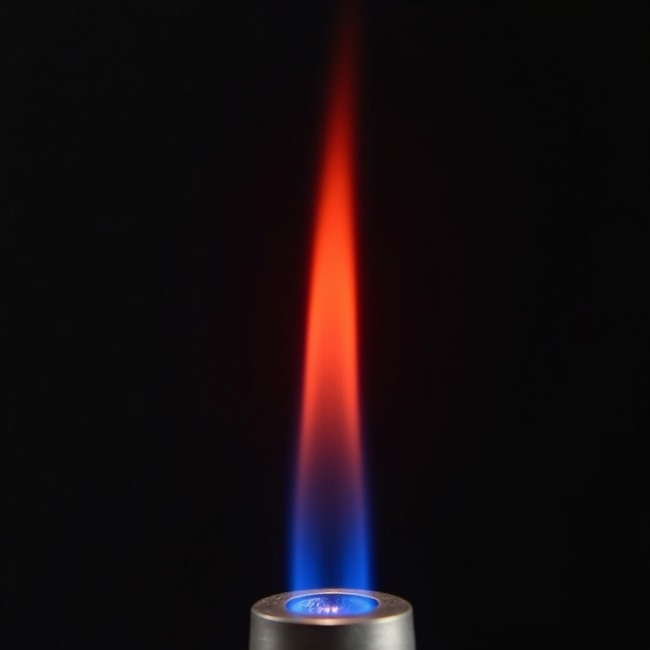
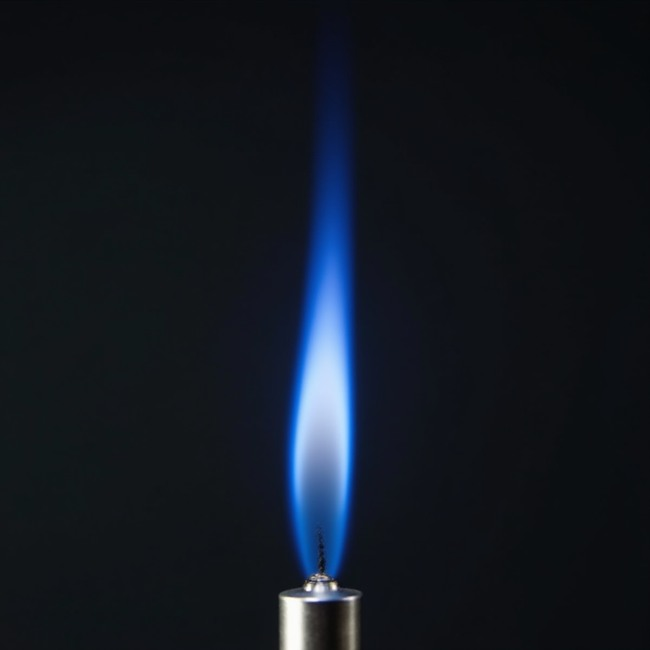
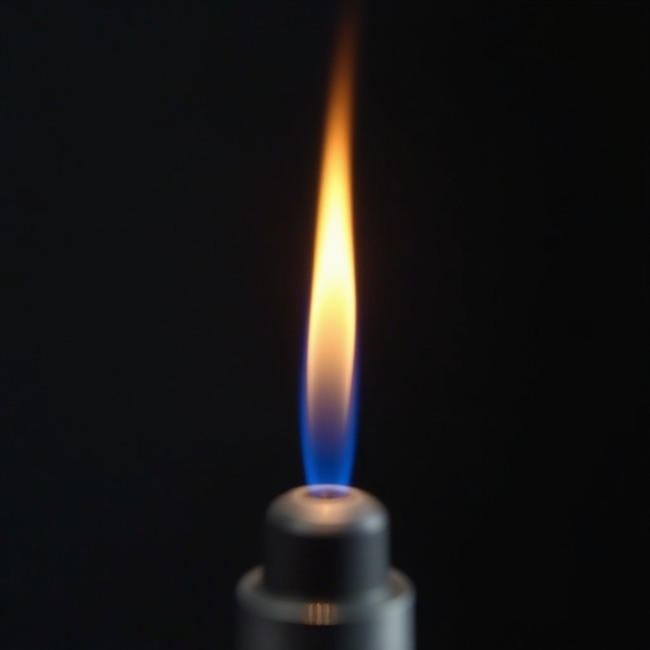
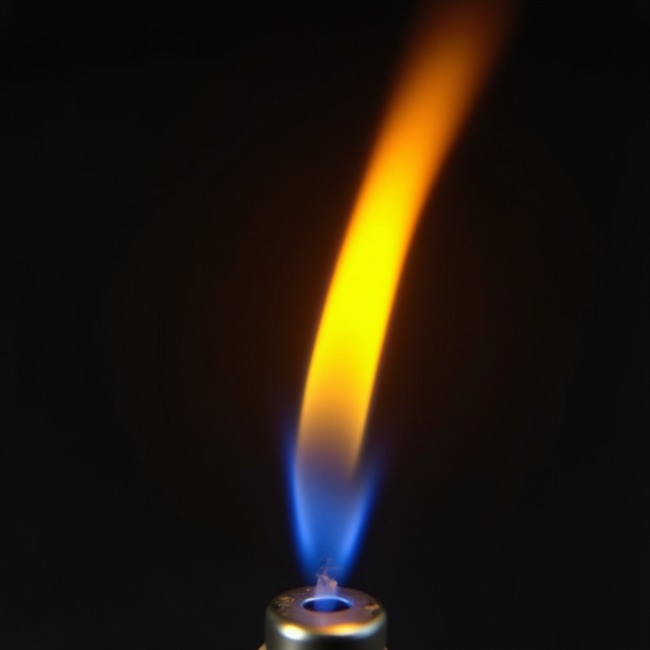
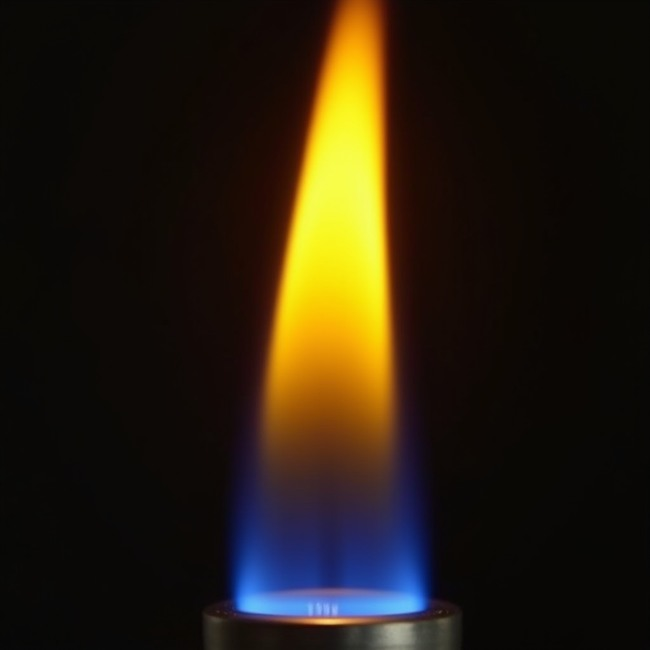
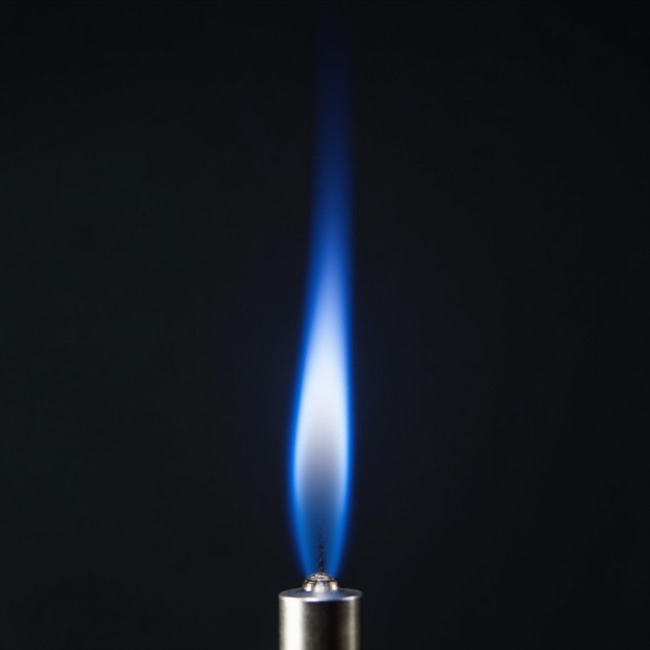
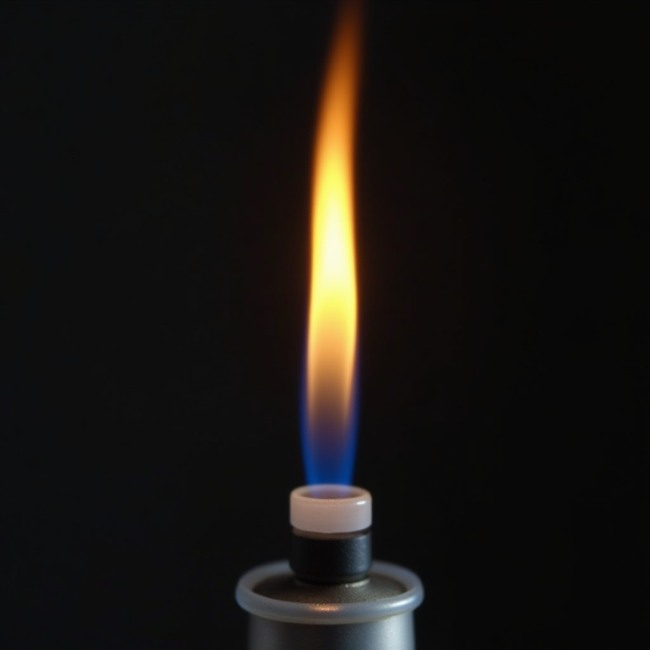
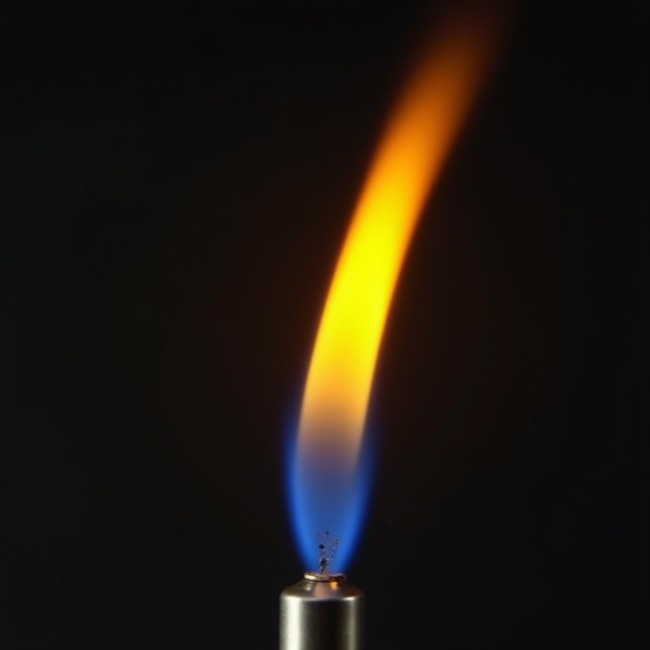
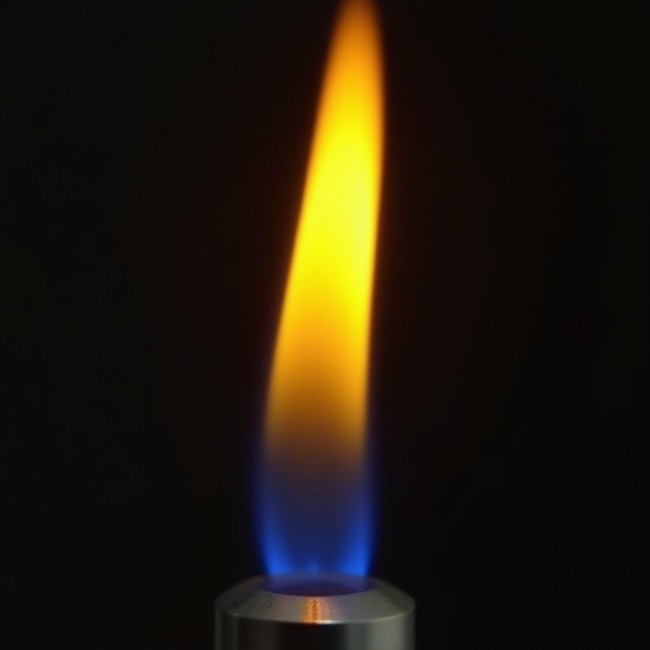
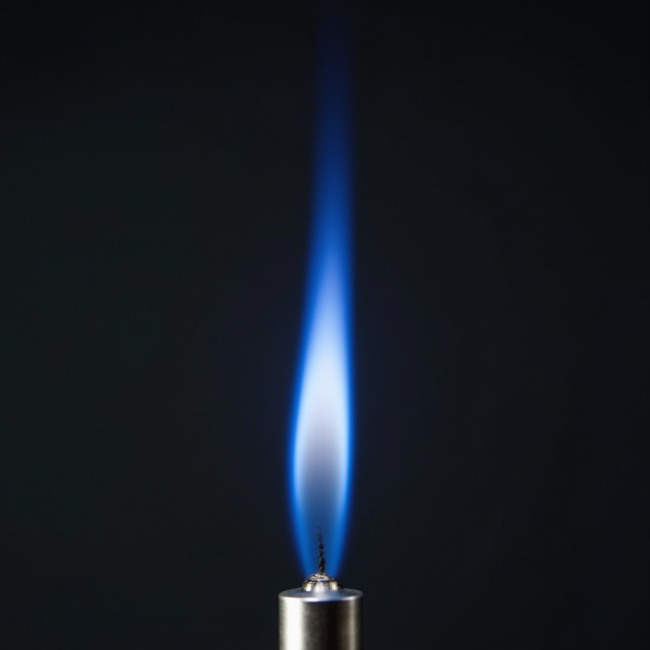
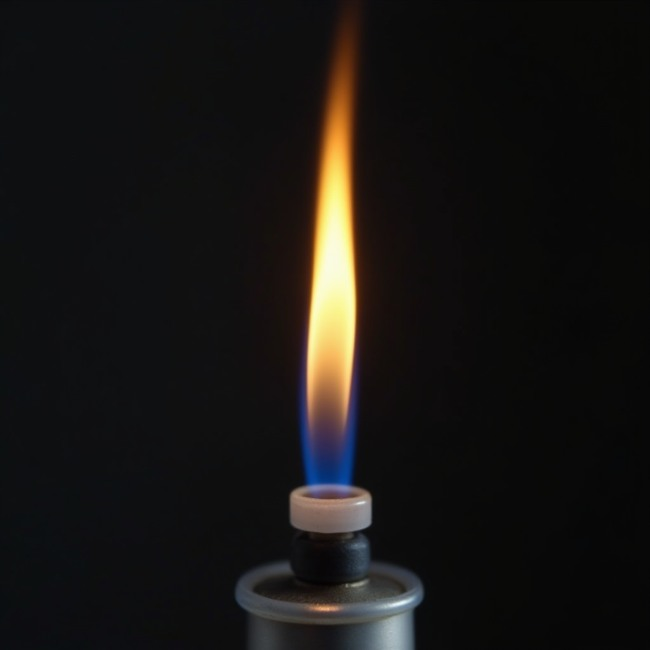
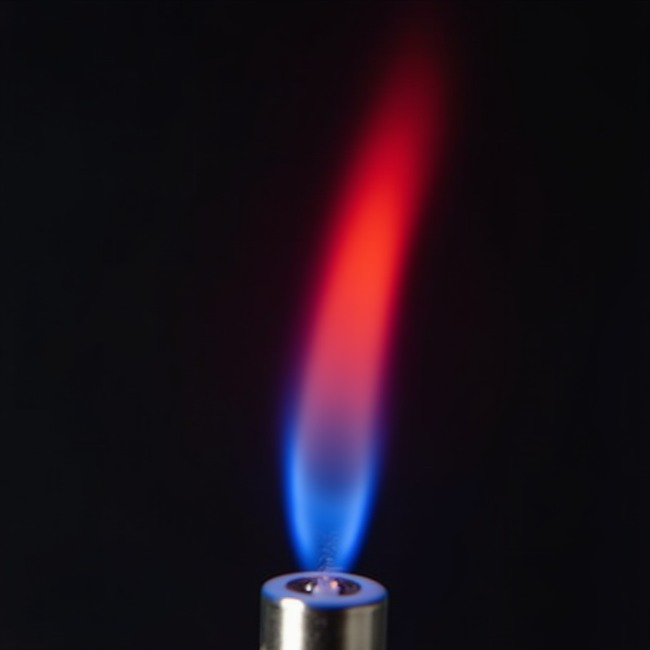
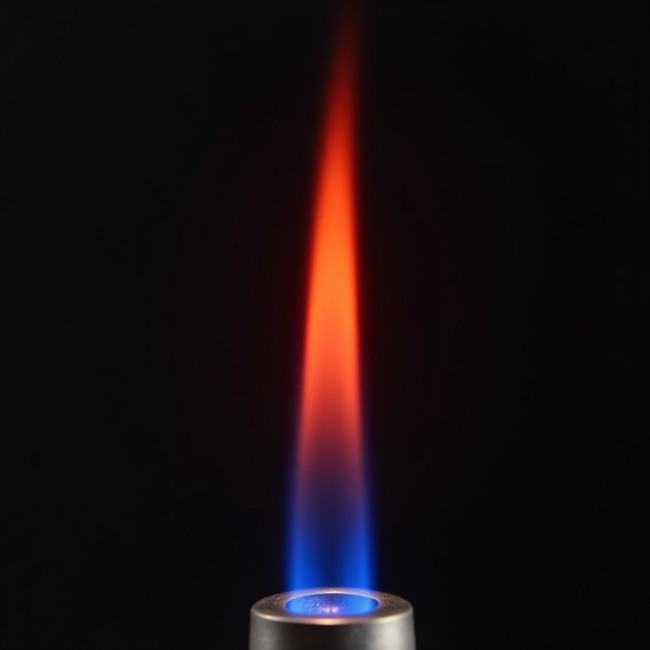

编译输入检查：
{
  "status": "accepted_for_controlled_development",
  "reviewer": "assistant/root",
  "human_gold": false,
  "reviewed_before_image_generation": true,
  "records_reviewed": 12,
  "caption_manually_edited": false,
  "checks": [
    "Correct arm selects only the requested entity: Araucana1/Marans0/Li3/Na2; all consequences match the supplied correct fact.",
    "Wrong arm selects same entity and preserves deliberately swapped color; not source-supported or trustworthy data.",
    "Empty arm uses no fact IDs, does not explicitly add target colors; eggs exactly repeat the source prompt. This is one fixed compiler prompt, not the strongest possible planning baseline.",
    "All captions preserve single subject, target scene, view, lighting and no-text requirement.",
    "Flame captions sometimes turn optional blue base/bright core into visible detail; it is an allowed drawing variant and is not a new knowledge criterion.",
    "No target image, closed-model output, or hand-edited a

In [2]:
display(HTML(render(transfer)))
print('编译输入检查：')
print(json.dumps(json.loads((transfer/'compiler_review.json').read_text()),ensure_ascii=False,indent=2))

## 出题与可绘制性检查

4 道颜色题分别比较原题、直接资料拼接、中性场景扩写和助手编写的显式视觉 caption；每条件 3 个配对种子。Gemini 只收到原题，每题生成 3 次。另有腰果与袋熊两道 caption 接口检查，各 9 张 BAGEL 图，没有新增闭源对照。

“知识符合”只表示冻结的视觉属性符合。目标缺席、额外动物或文字、无法观察及材料质感，必须结合逐图记录阅读。

案例,baseline,knowledge,irrelevant,explicit,Gemini baseline
APA标准 Araucana 蛋,0/3知识＋构图 0/3,2/3知识＋构图 1/3,0/3知识＋构图 0/3,3/3知识＋构图 3/3,2/3知识＋构图 2/3
APA标准 Marans 蛋,0/3知识＋构图 0/3,0/3知识＋构图 0/3,0/3知识＋构图 0/3,3/3知识＋构图 3/3,3/3知识＋构图 3/3
lithium chloride 干净焰色试验,0/3知识＋构图 0/3,0/3知识＋构图 0/3,0/3知识＋构图 0/3,3/3知识＋构图 3/3,3/3知识＋构图 3/3
sodium chloride 干净焰色试验,3/3知识＋构图 3/3,2/3知识＋构图 2/3,3/3知识＋构图 3/3,3/3知识＋构图 3/3,3/3知识＋构图 2/3
腰果·完整未加工果实·自然caption接口,0/3知识＋构图 0/3,0/3知识＋构图 0/3,0/3知识＋构图 0/3,0/0,0/0
裸鼻袋熊·典型完整干燥粪便·自然caption接口,0/3知识＋构图 0/3,3/3知识＋构图 3/3,0/3知识＋构图 0/3,0/0,0/0

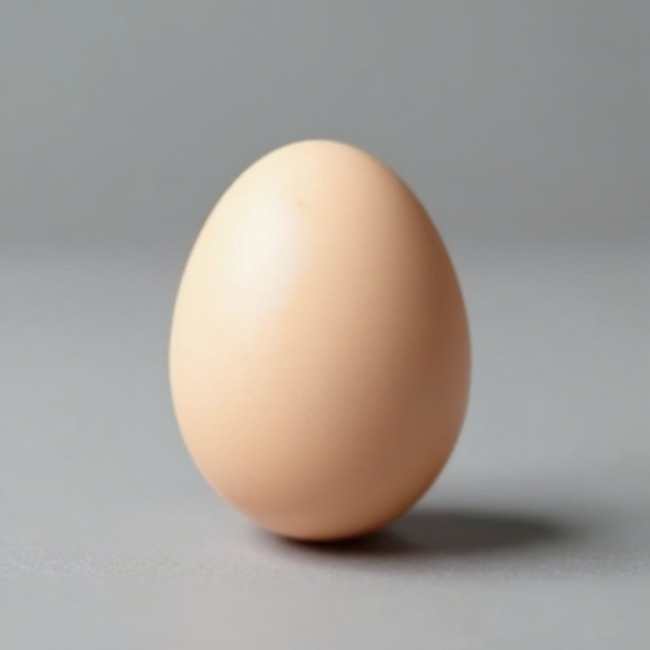
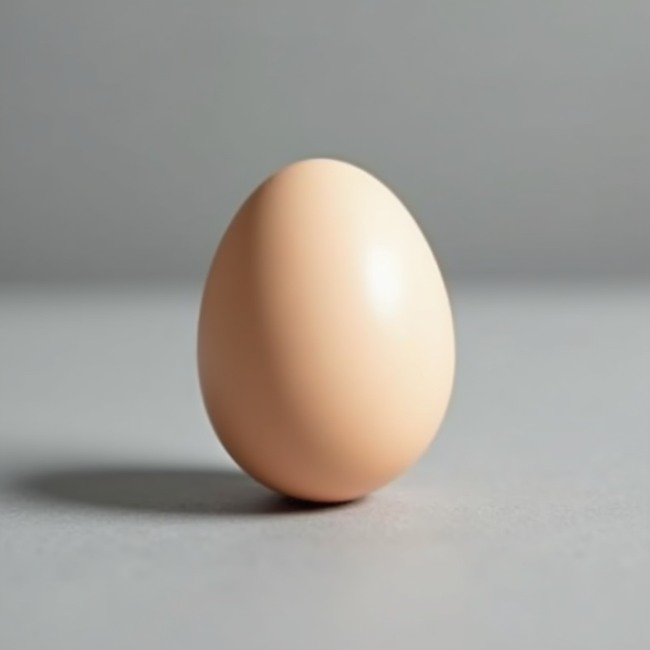
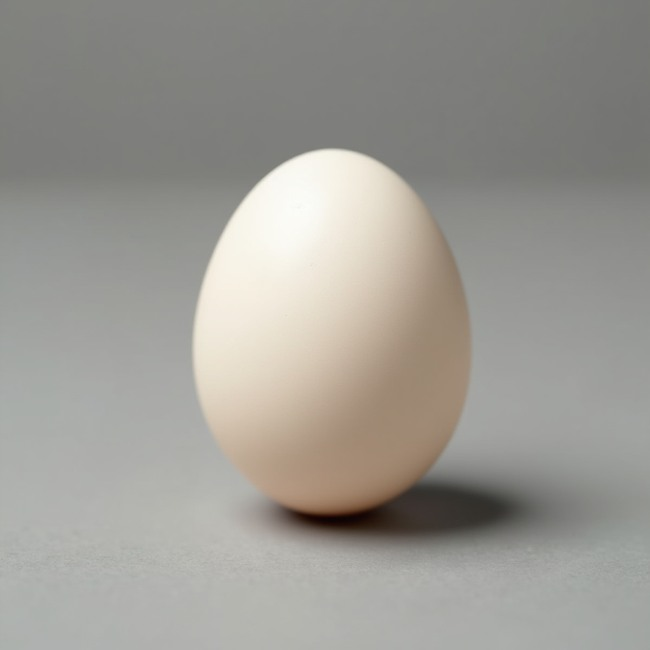
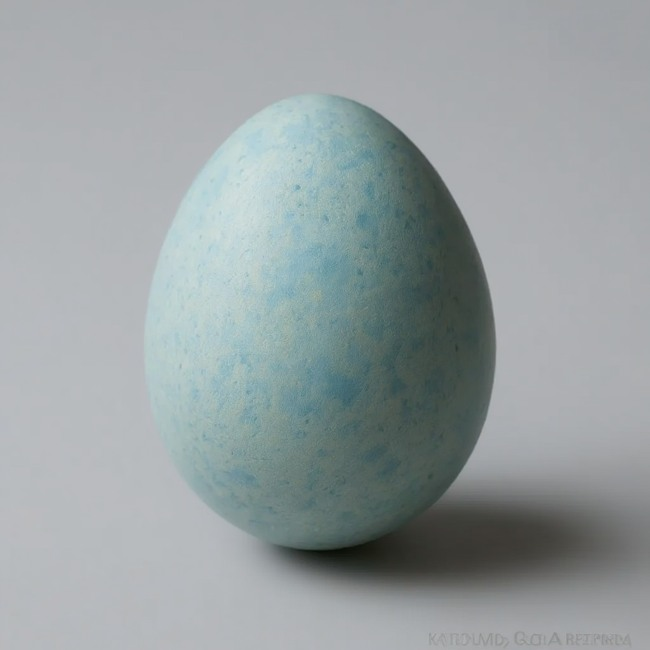
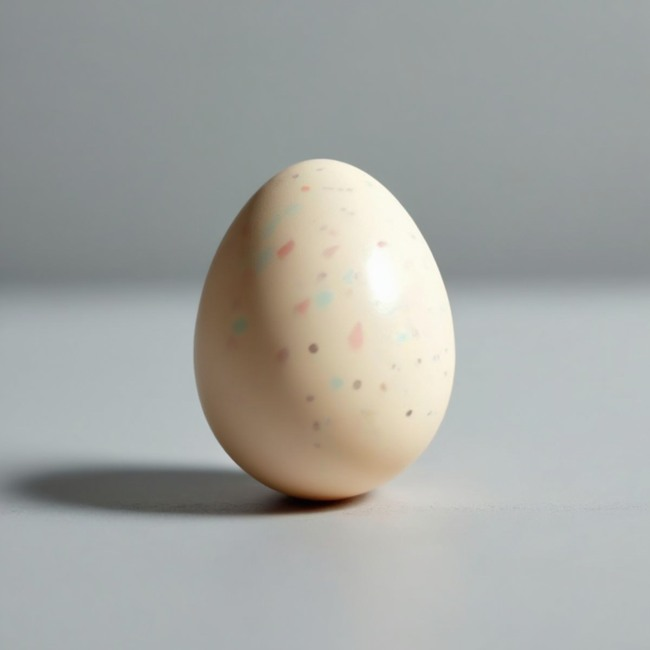
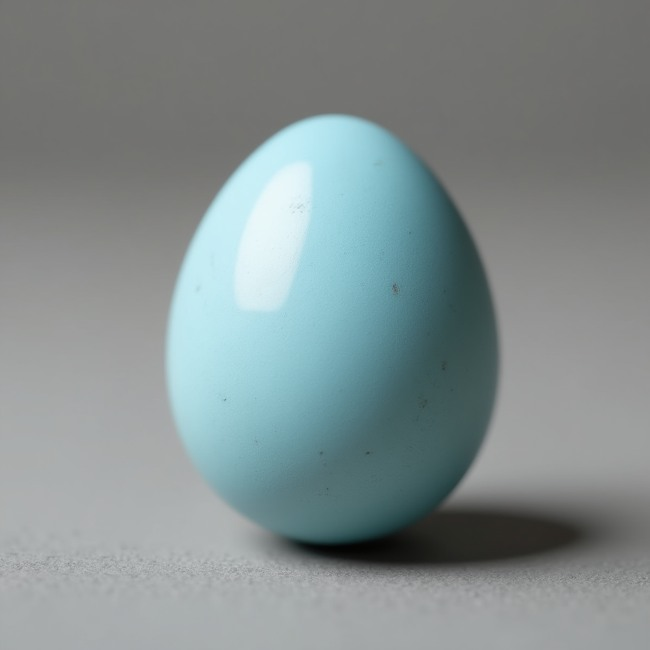
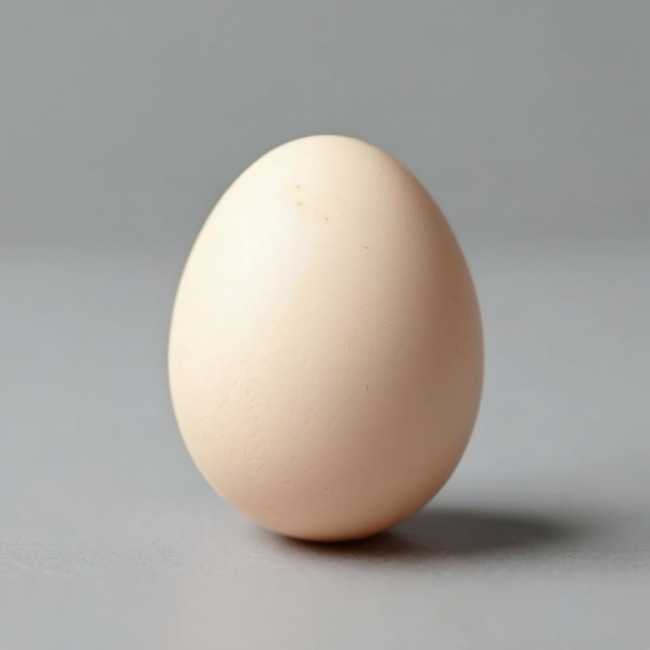
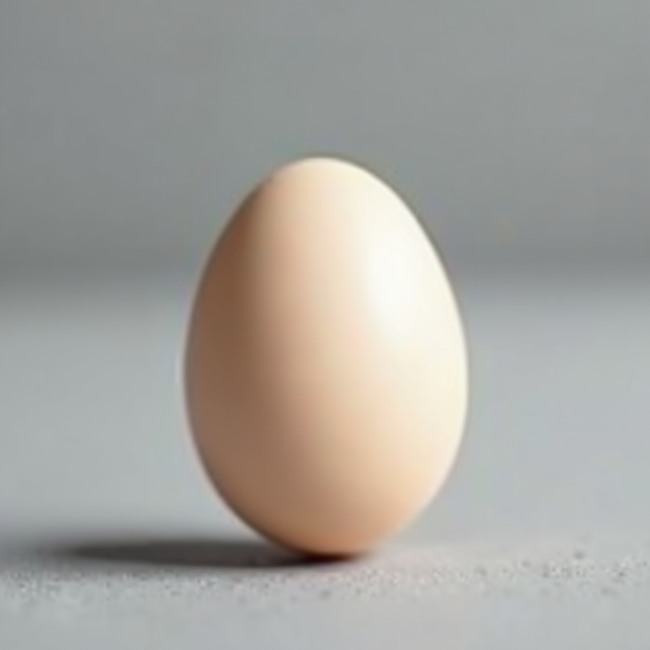
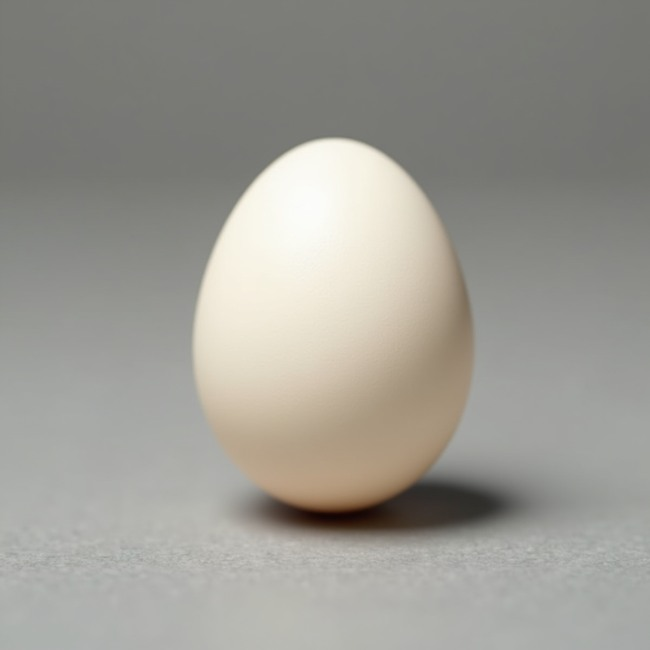
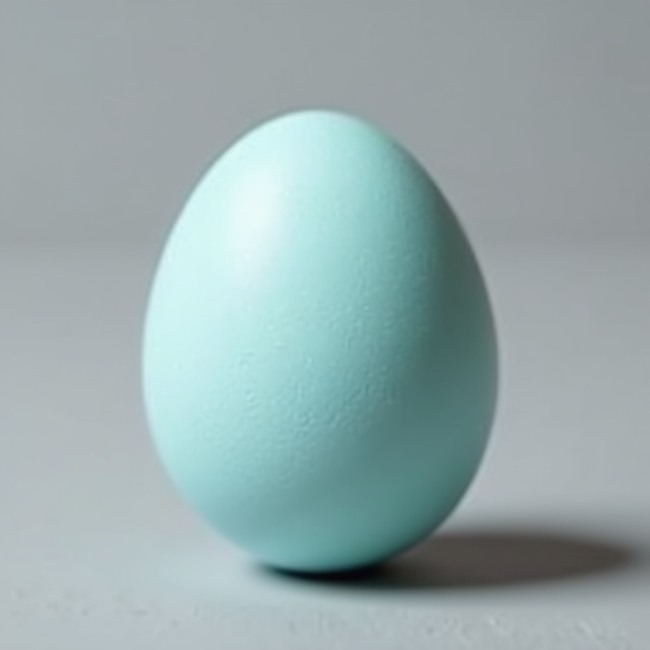
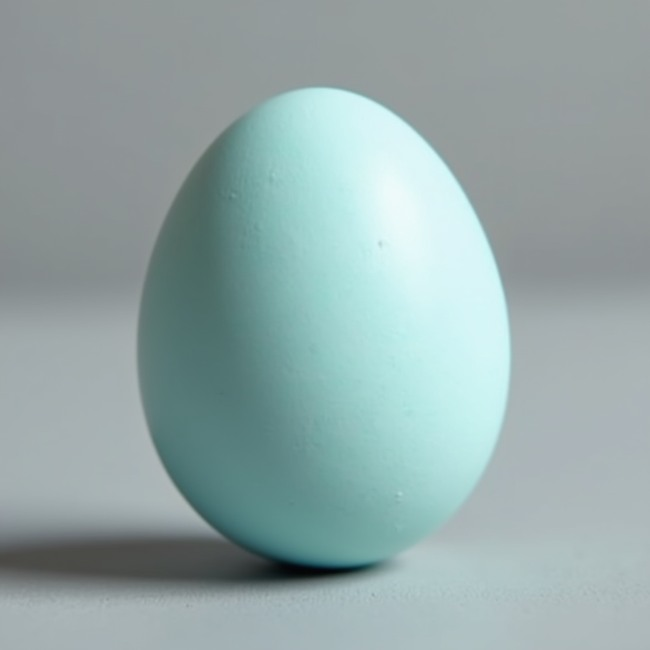
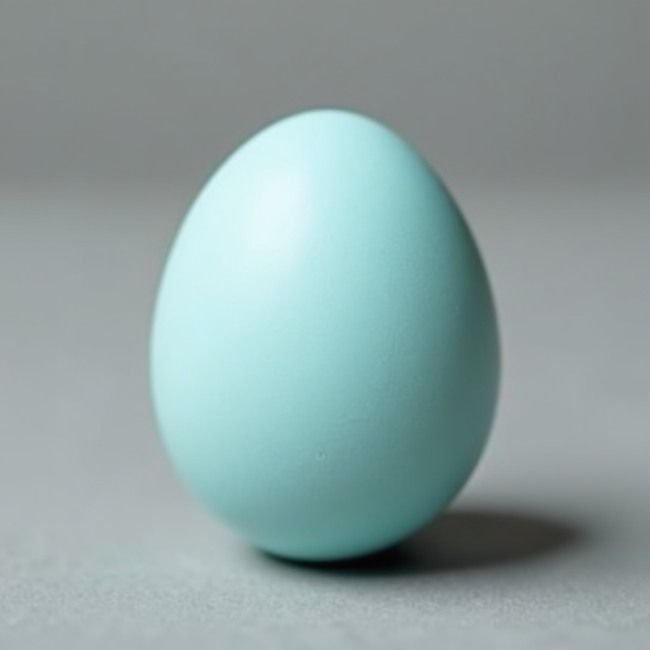
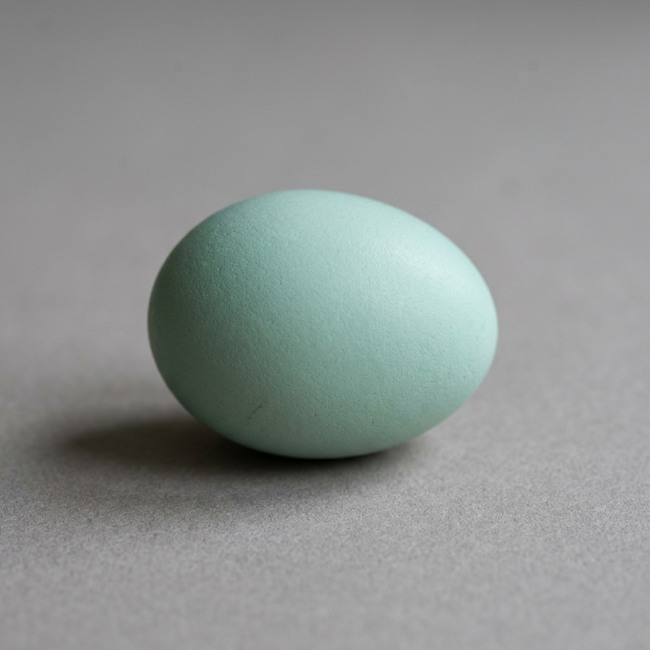
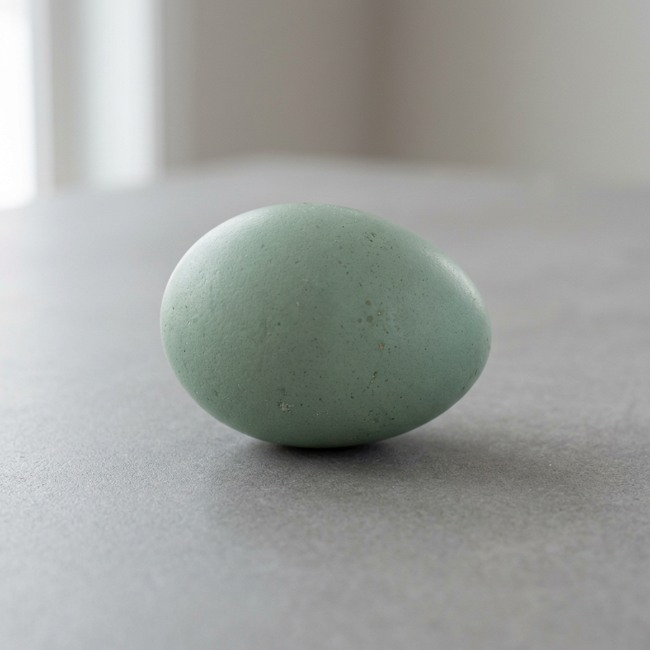
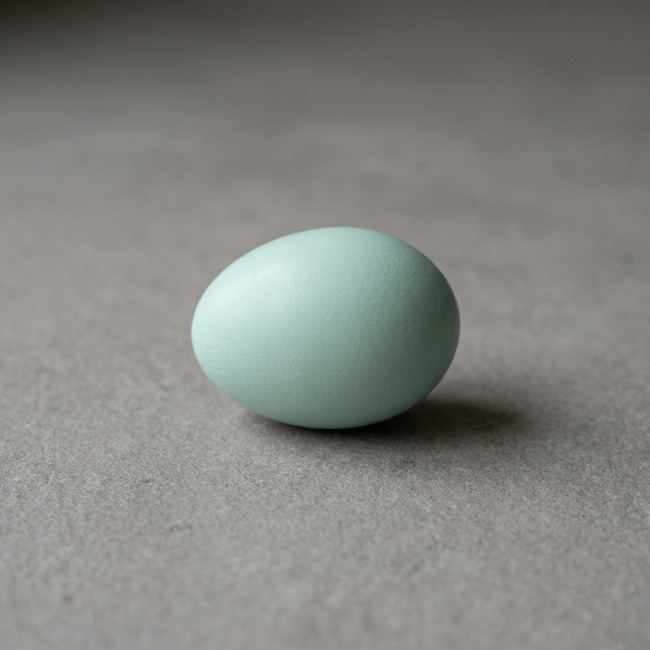
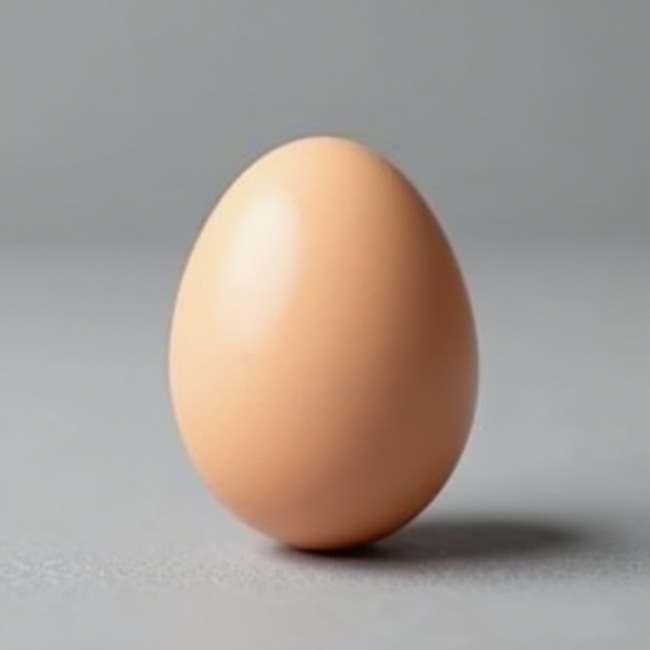
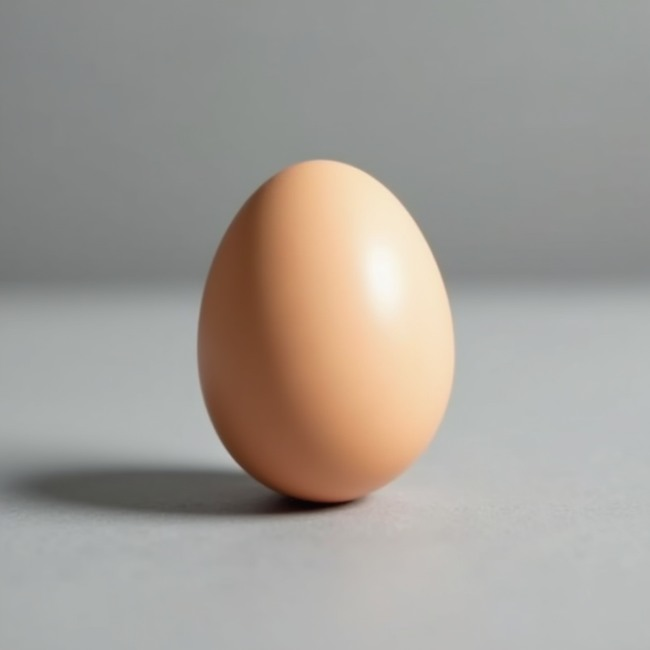
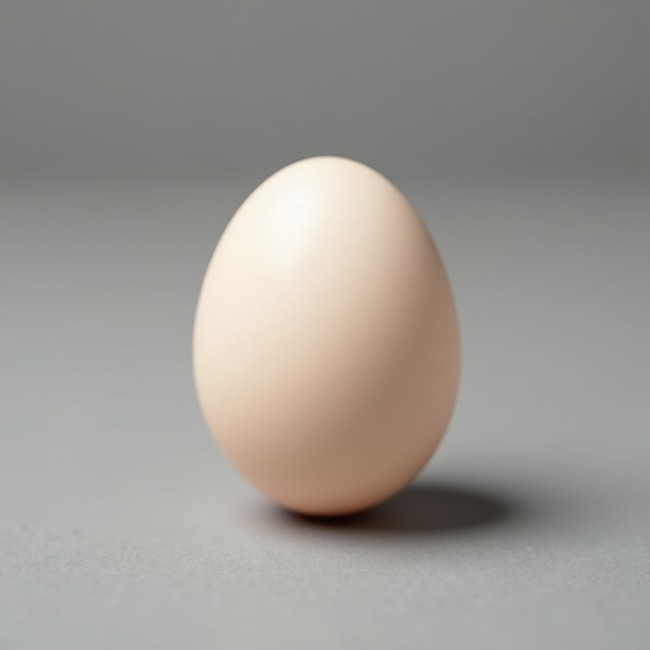
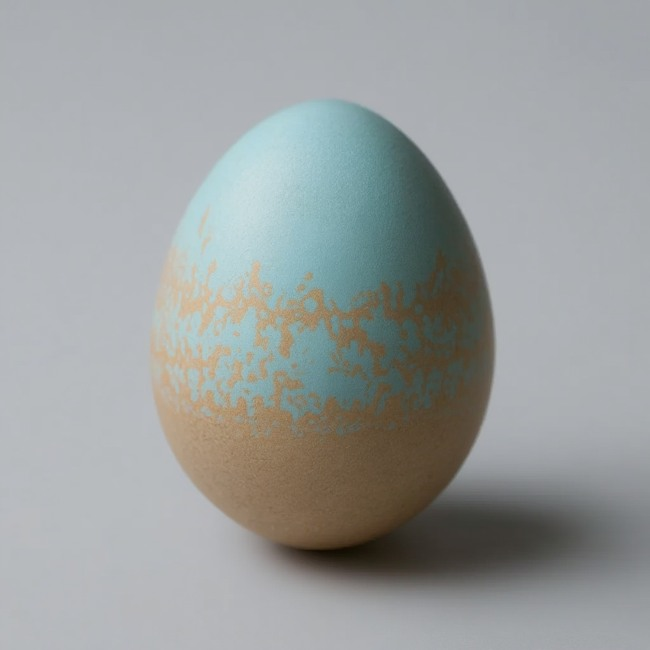
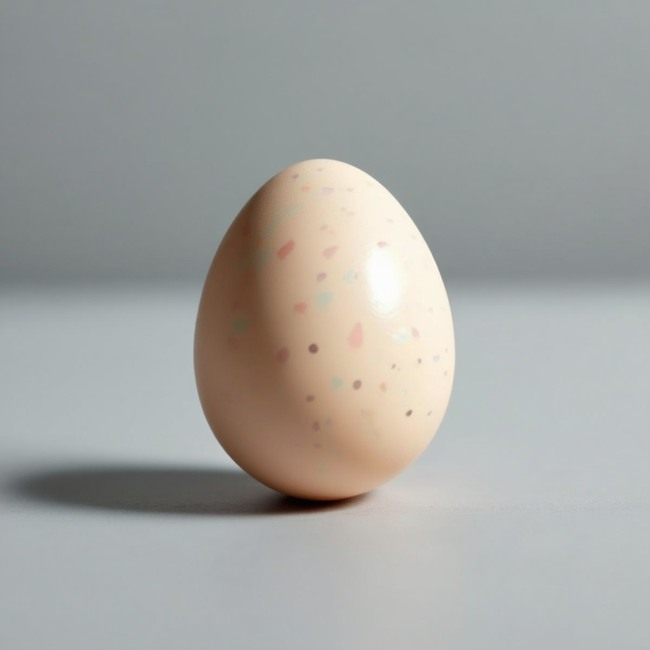
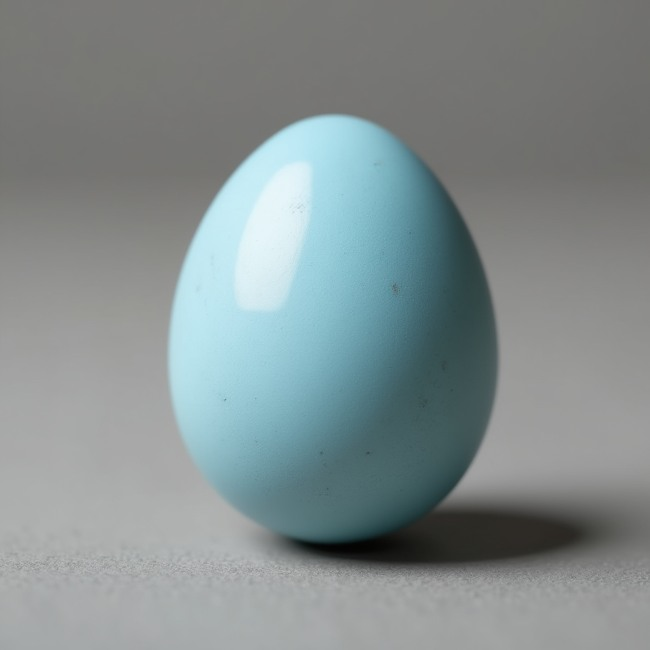
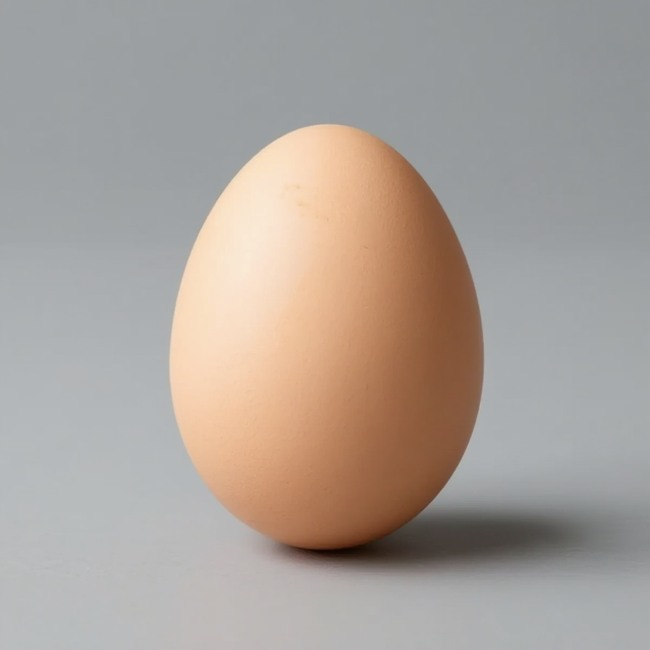
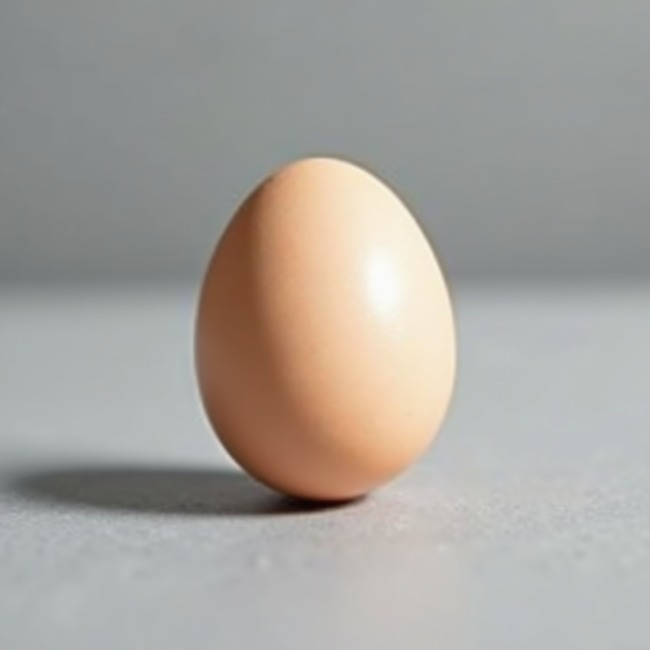
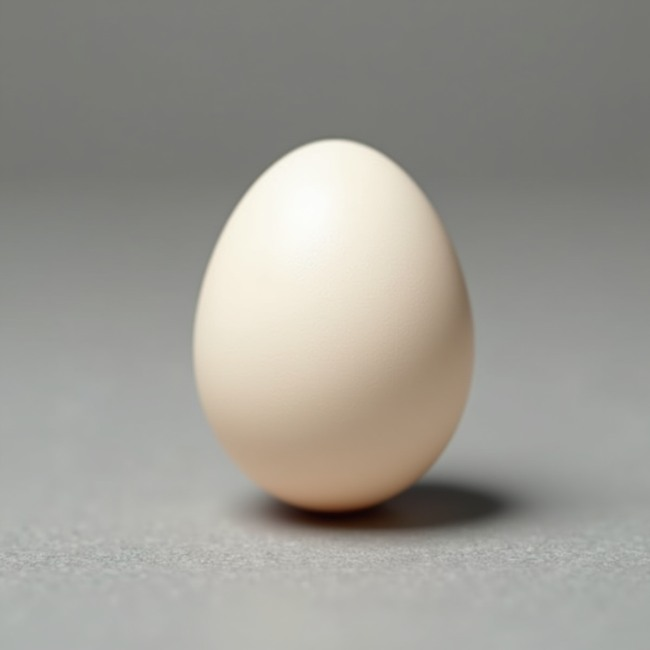
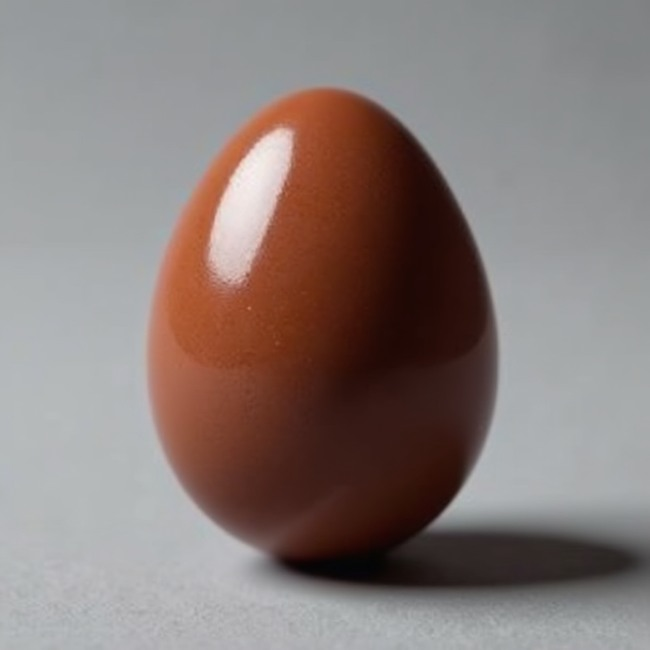
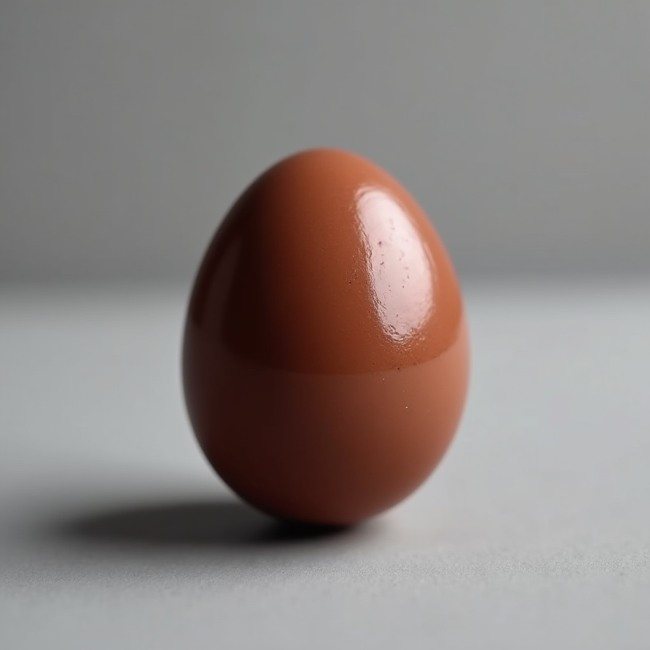
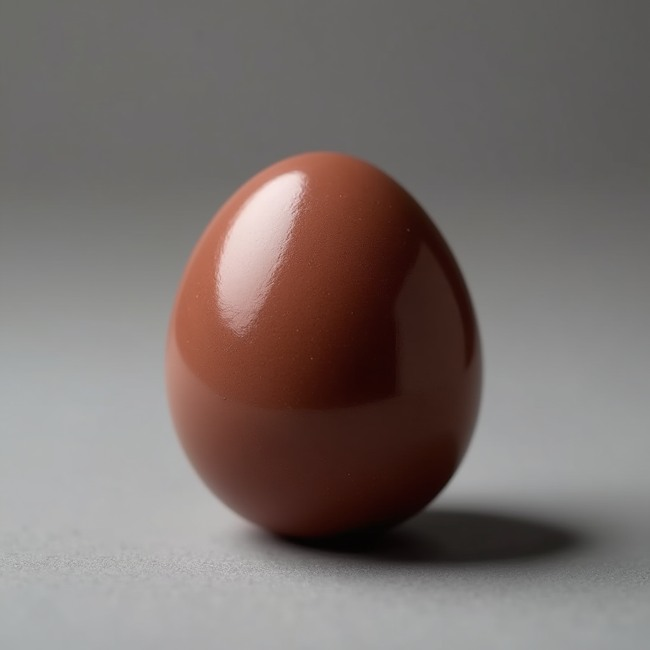
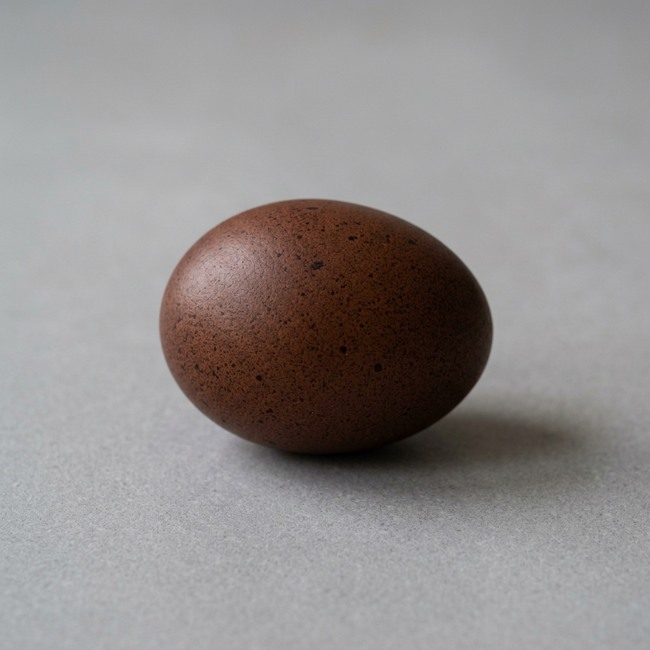
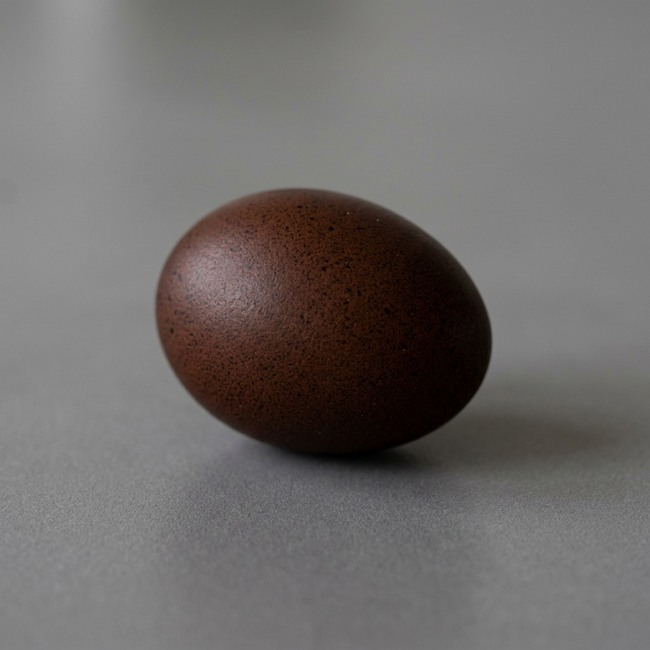
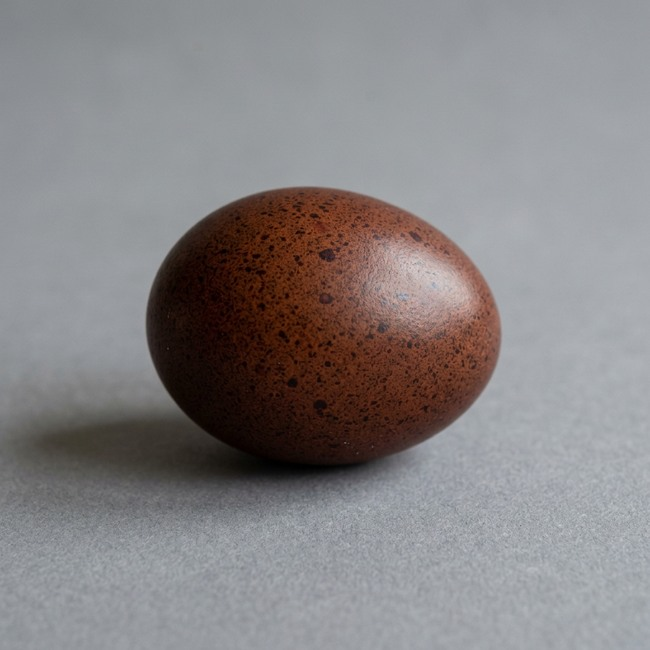
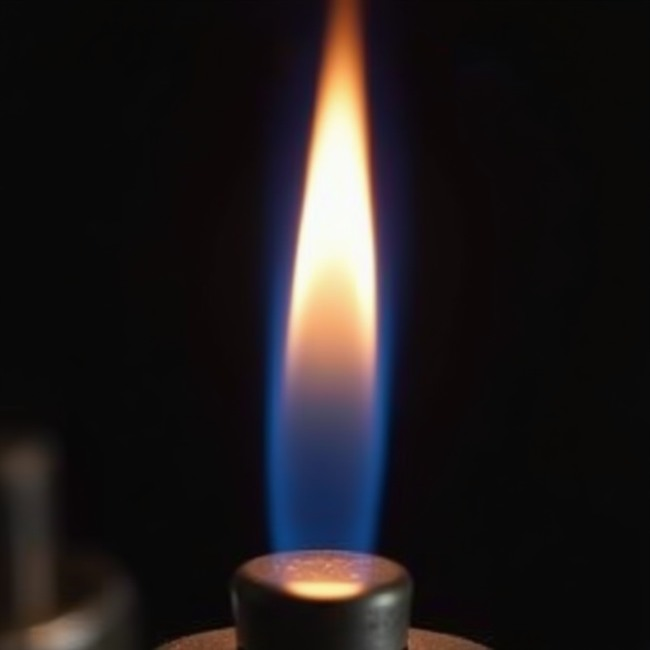
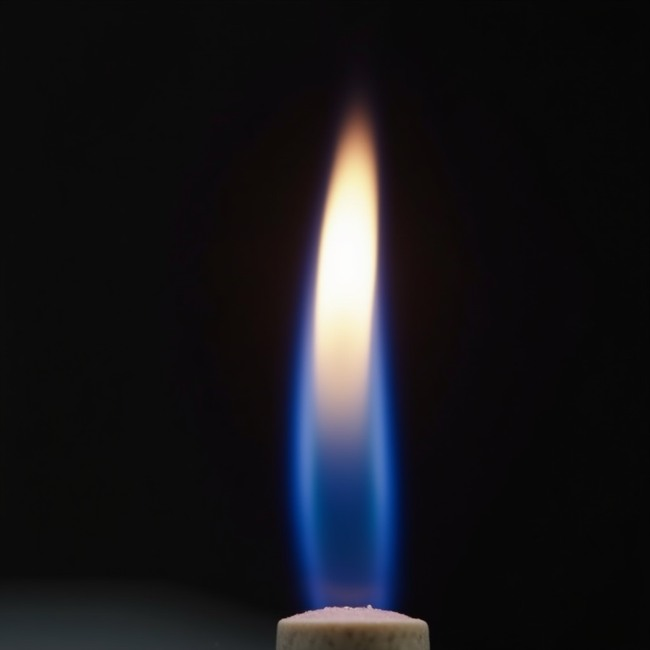
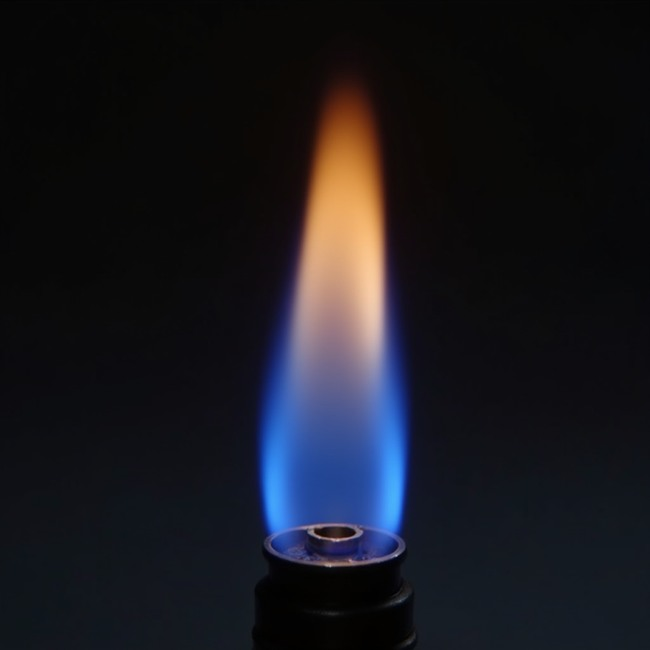
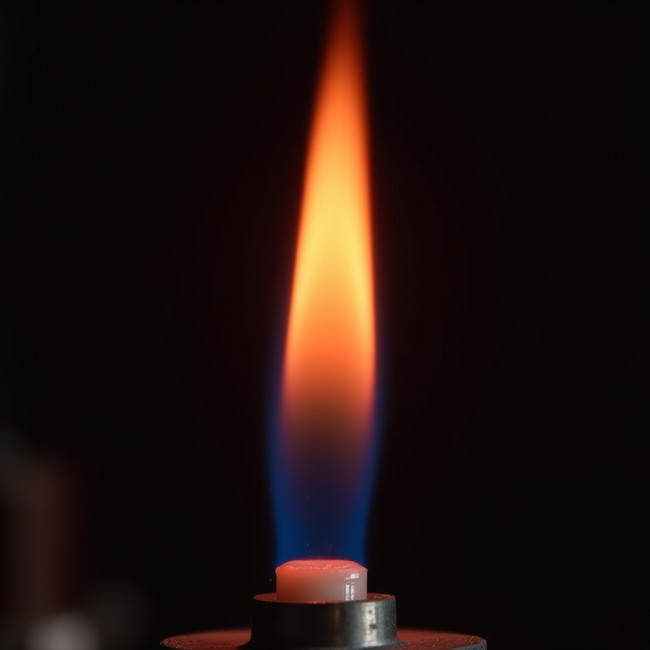
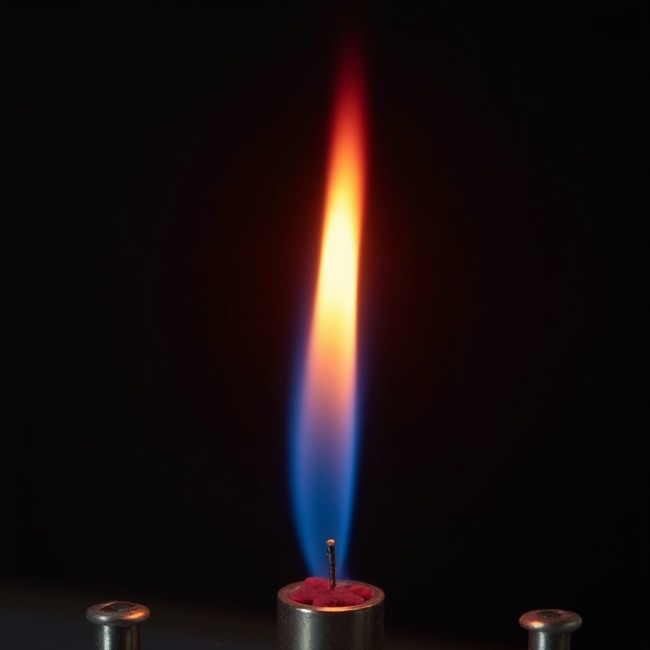
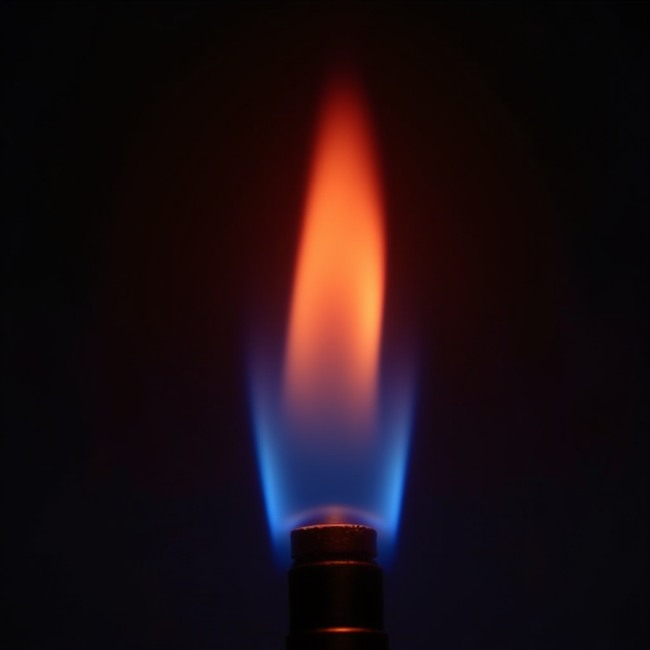
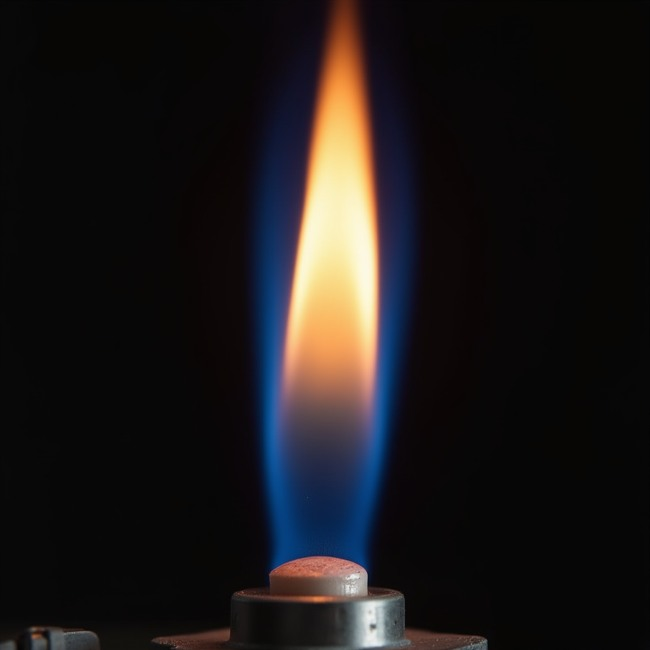
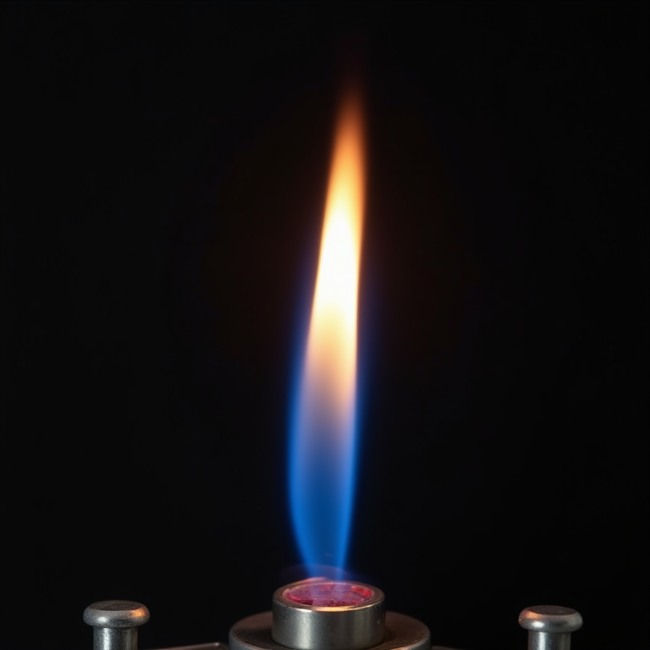
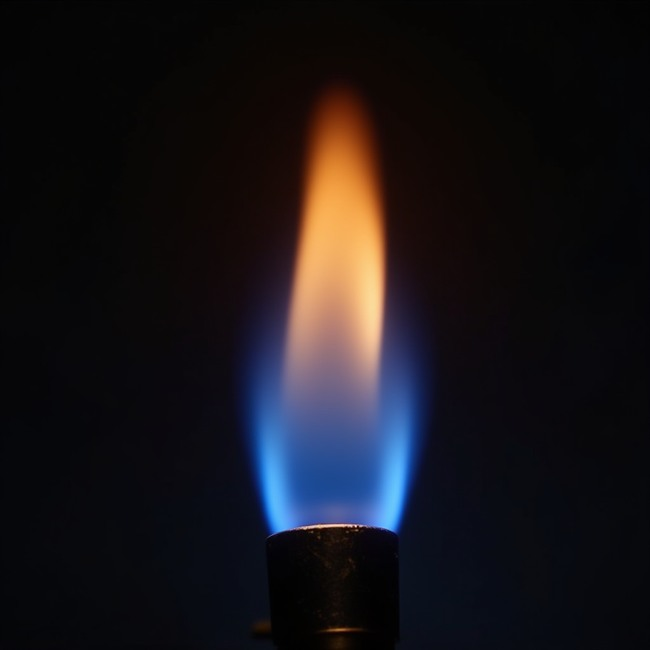
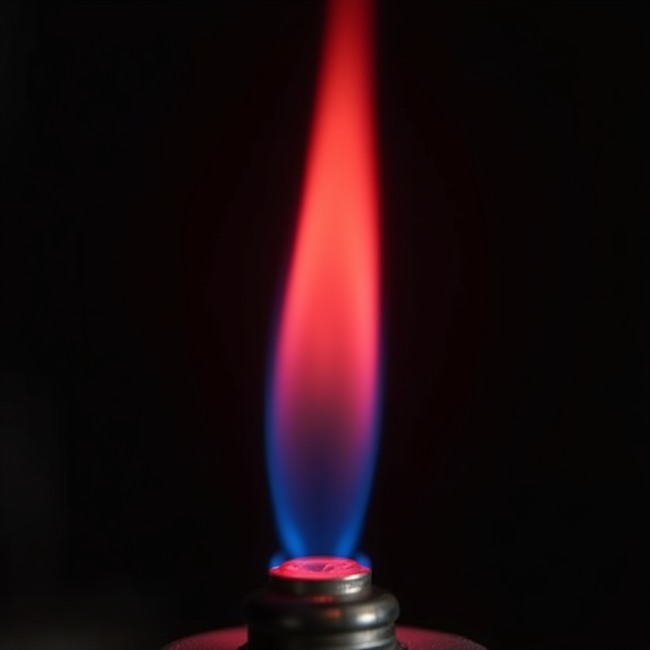
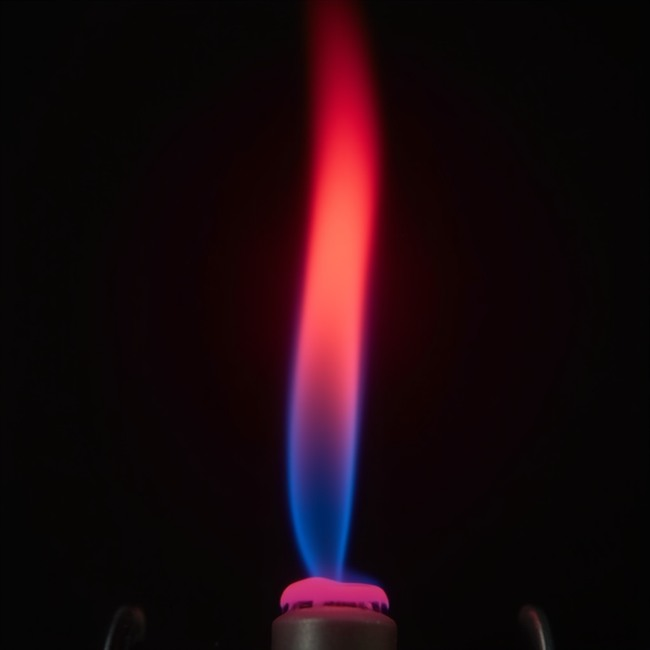
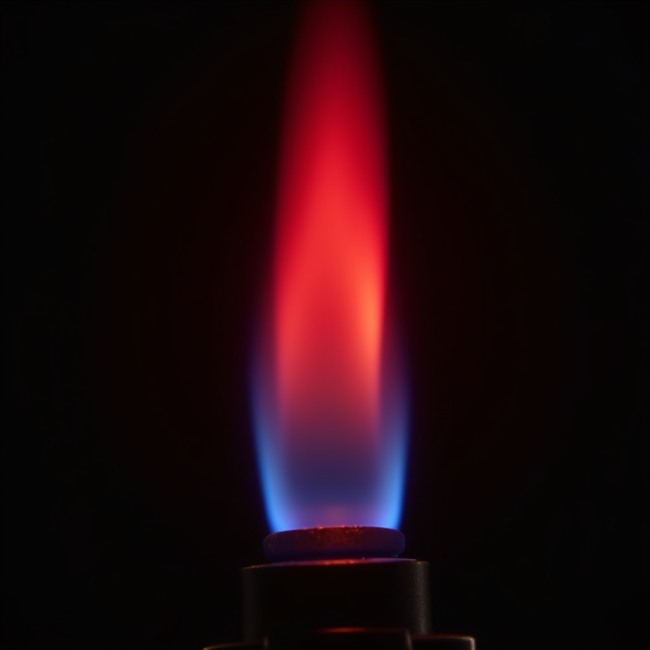
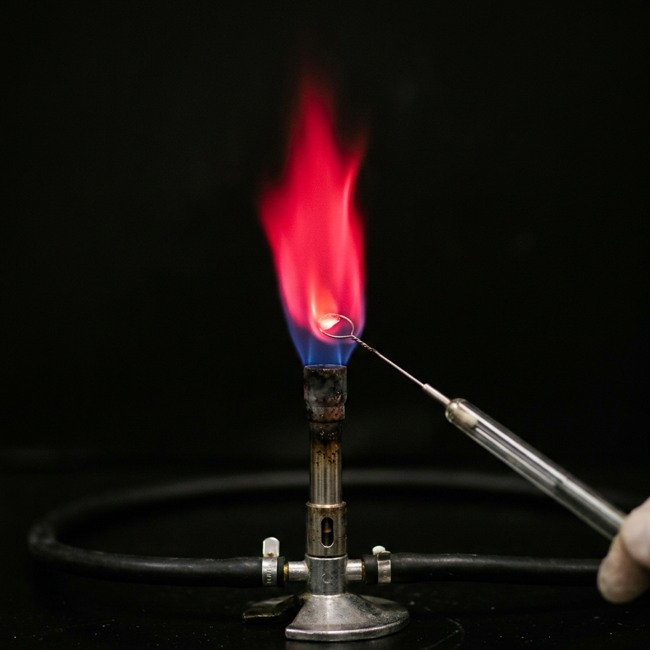
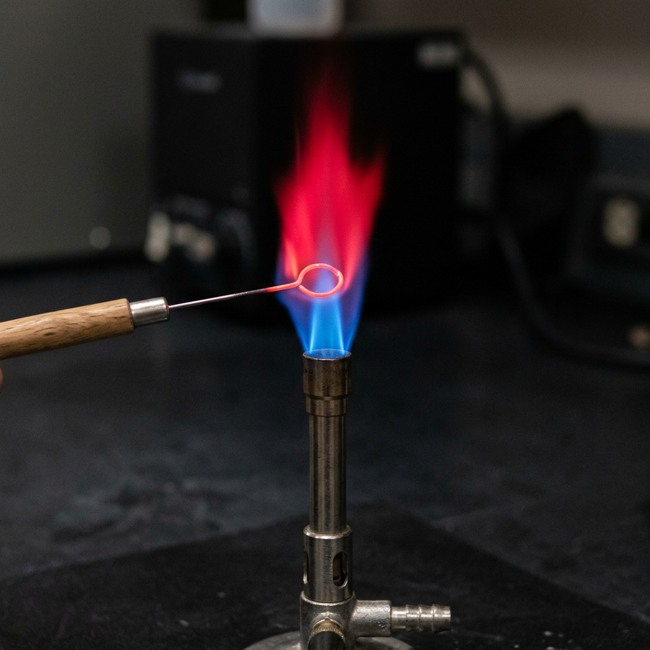
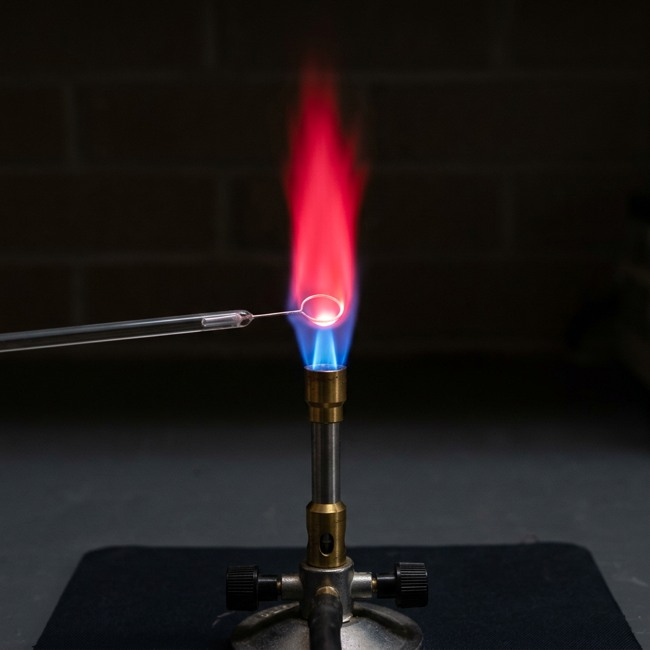
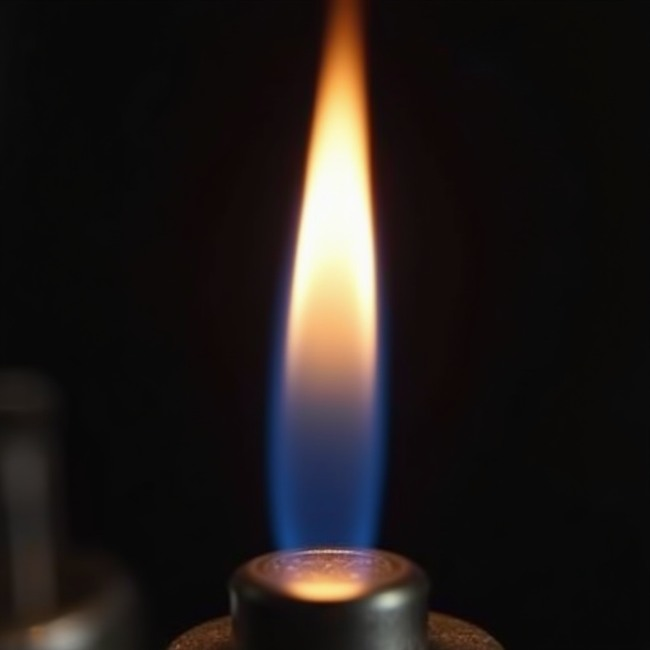
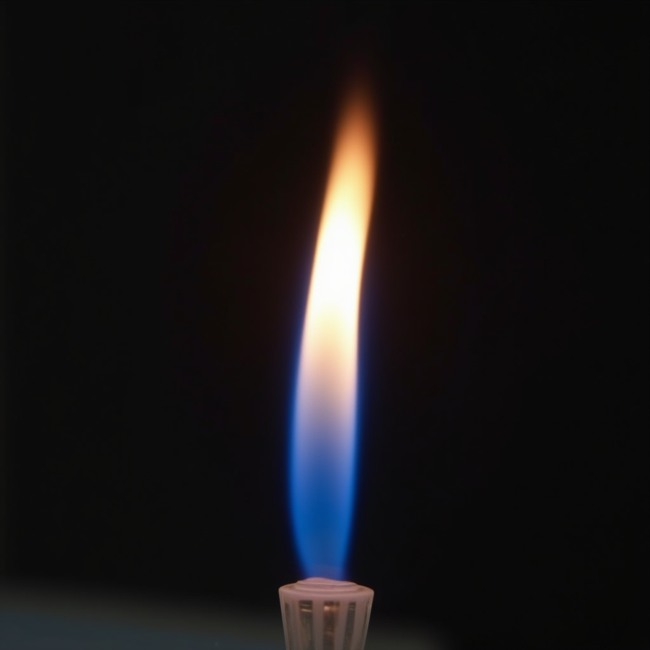
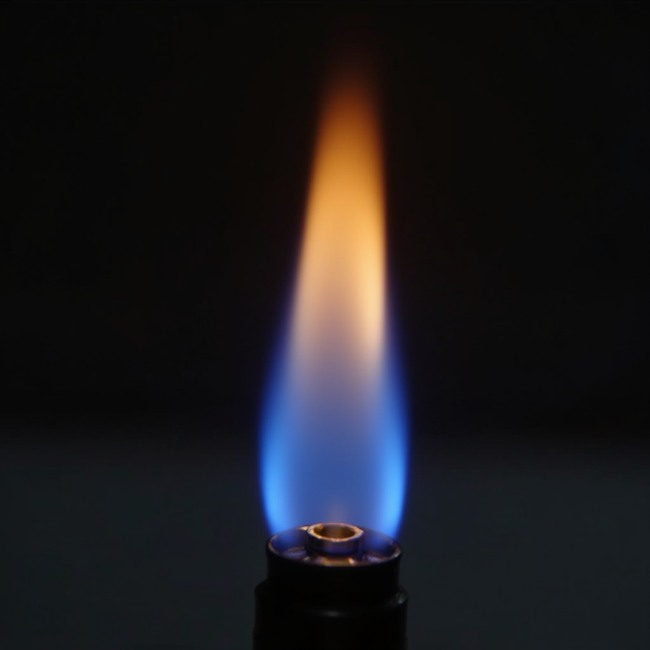
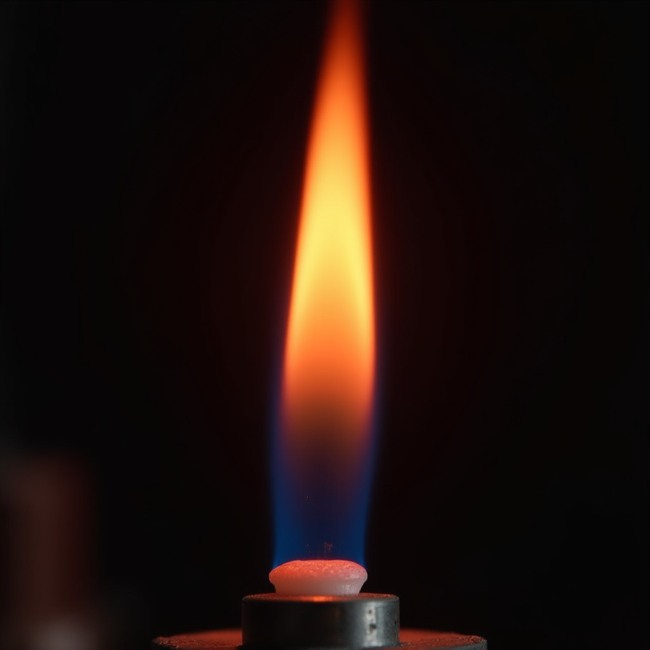
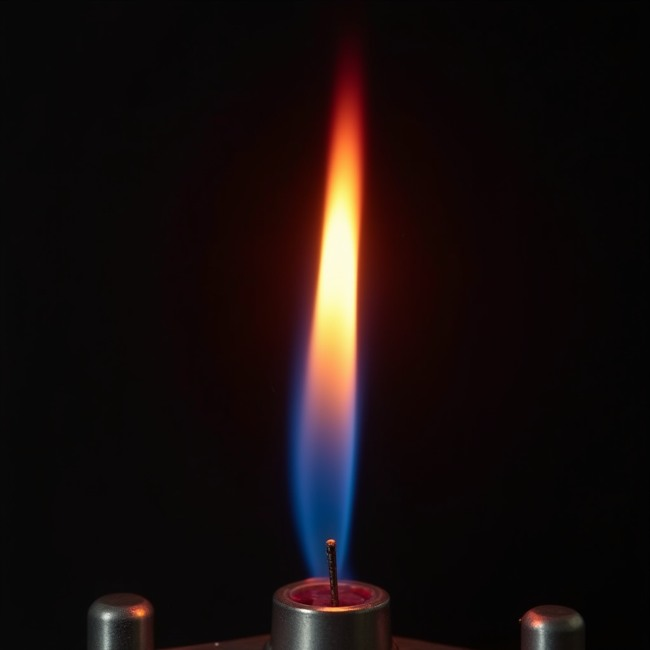
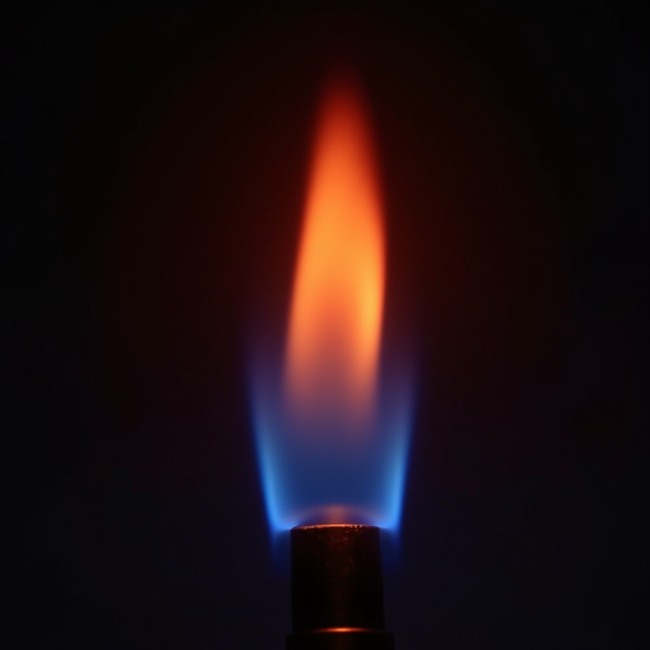
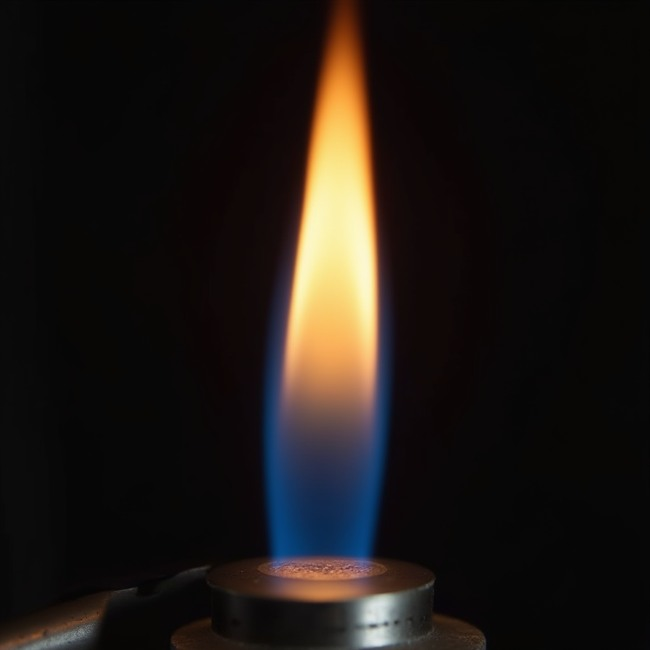
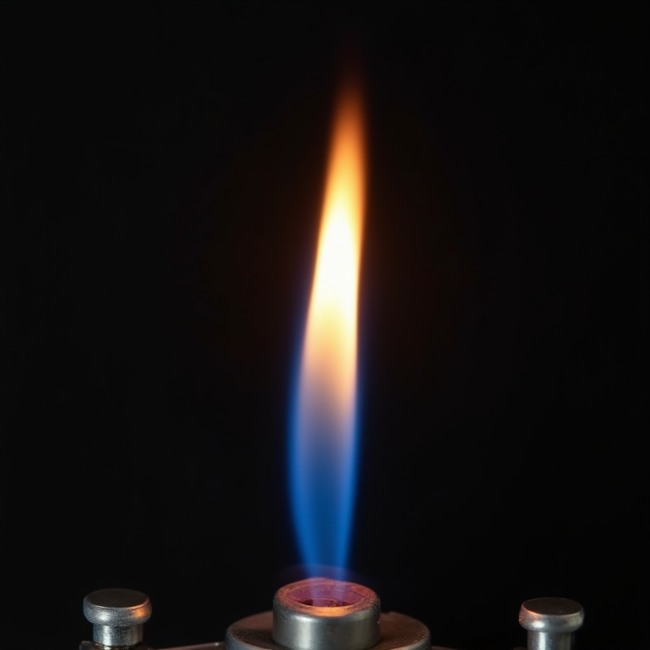
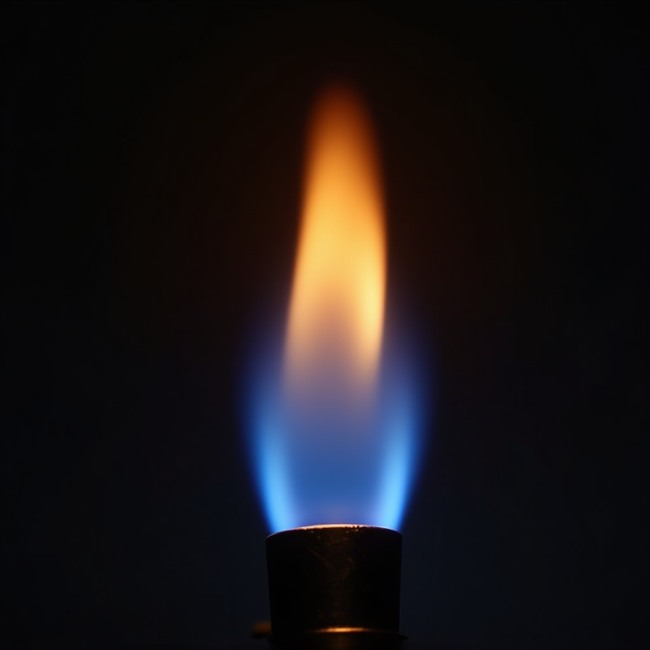
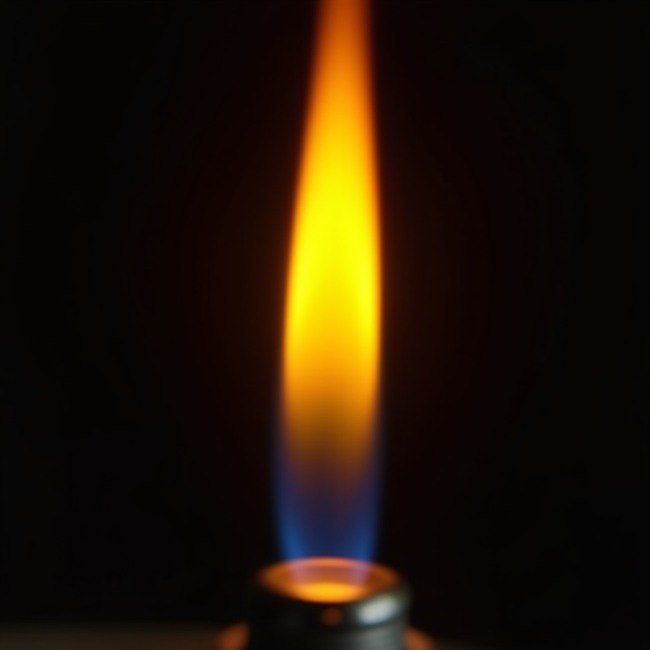
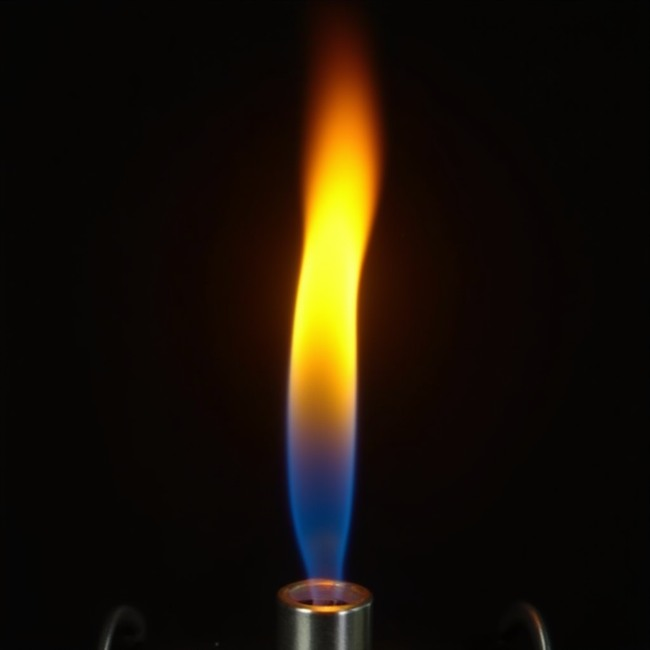
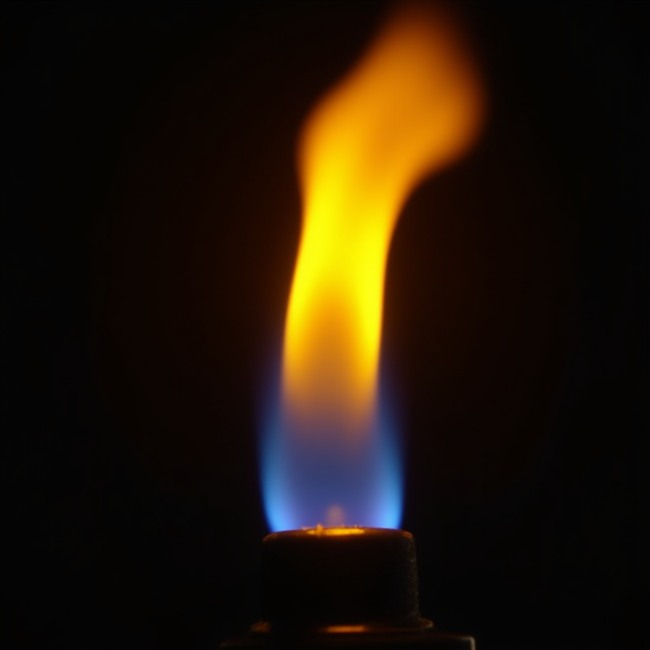
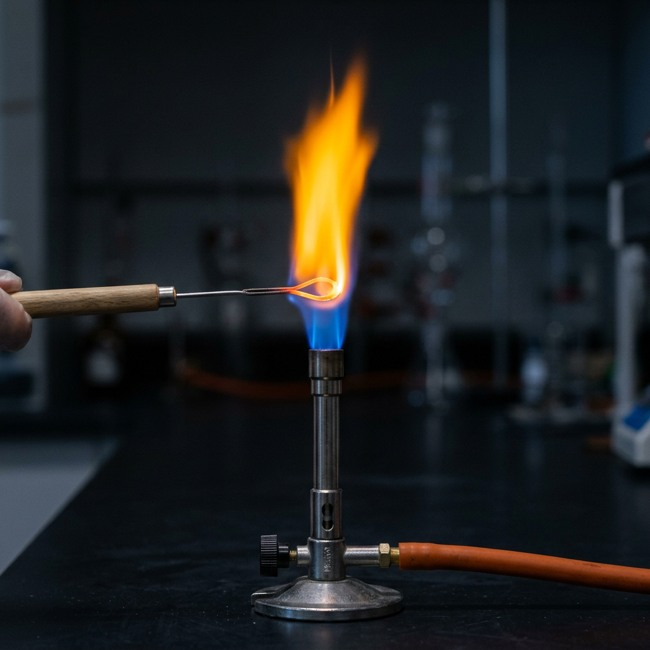
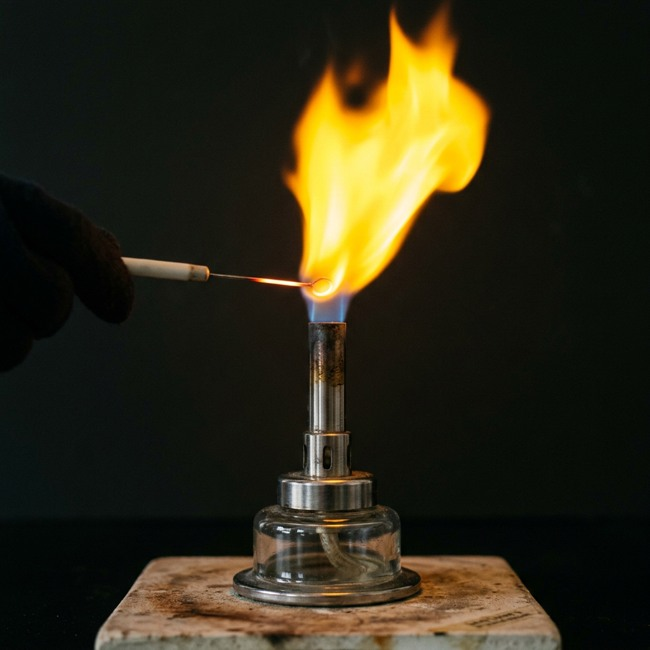
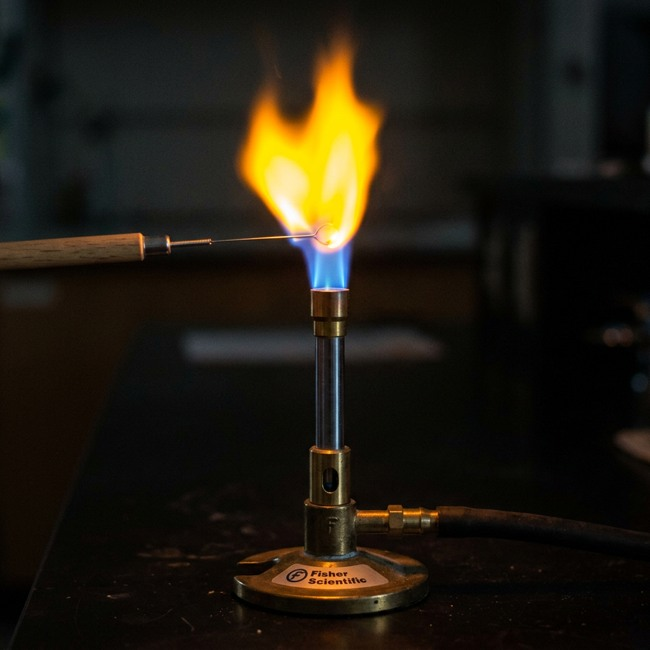
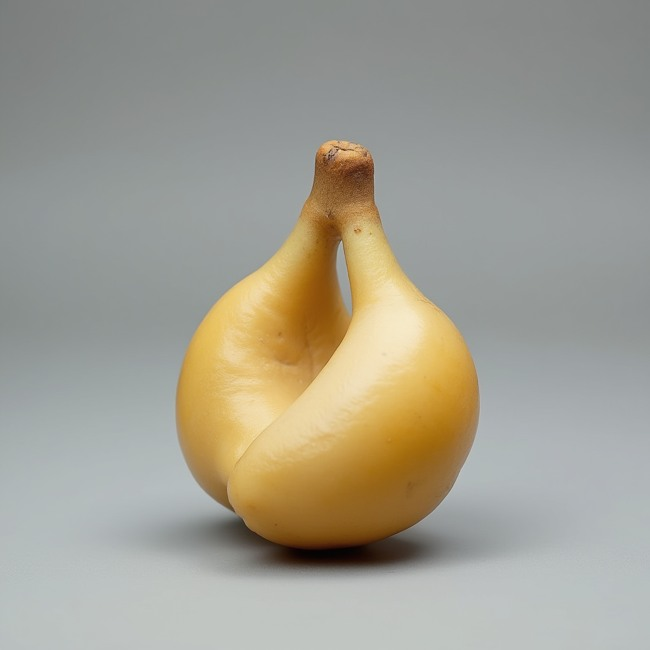
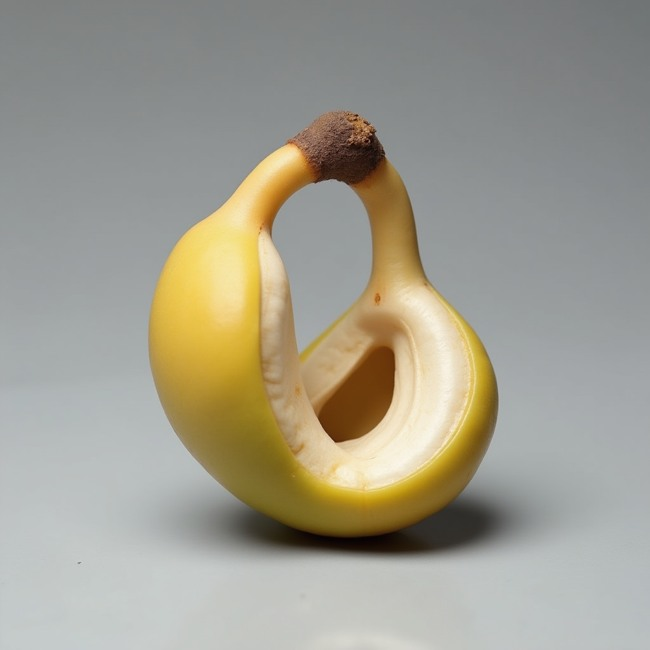
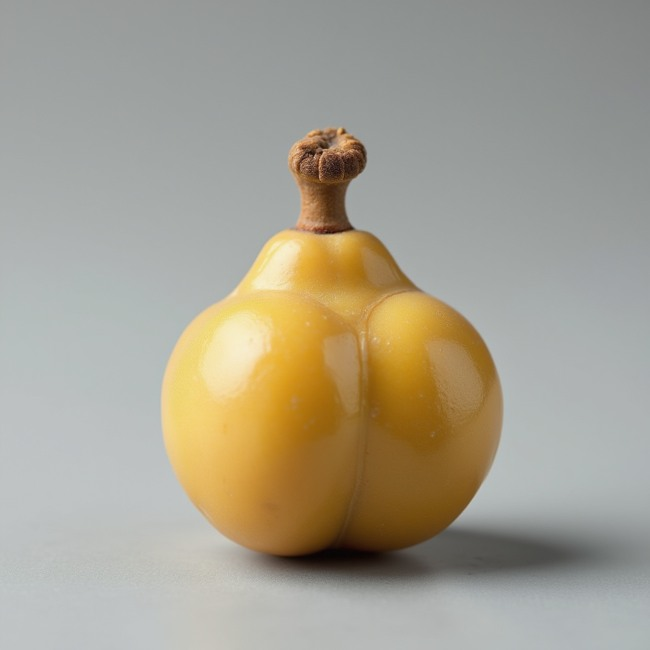
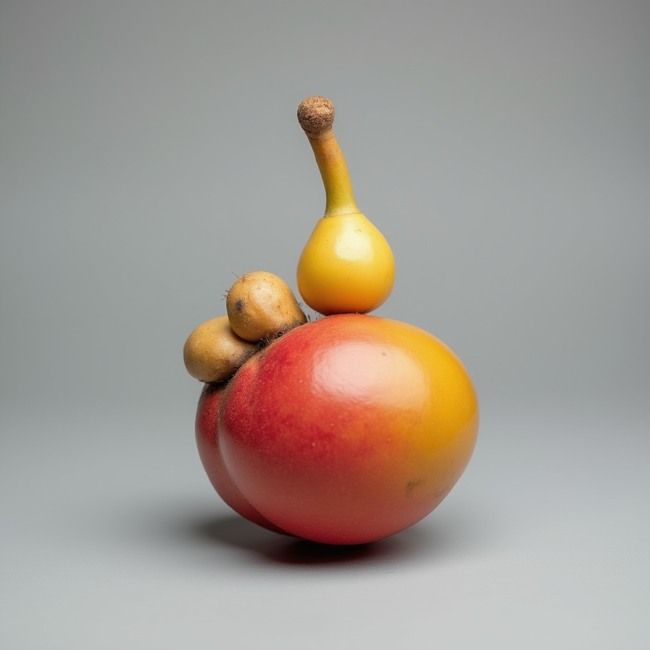
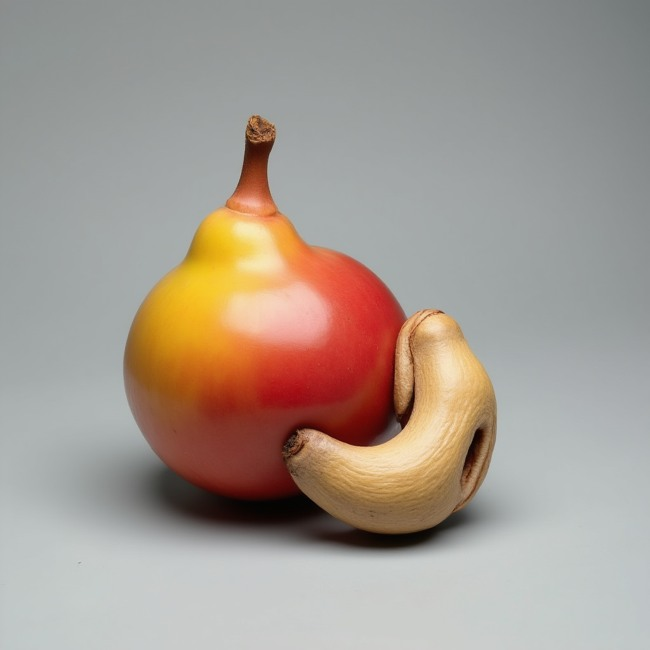
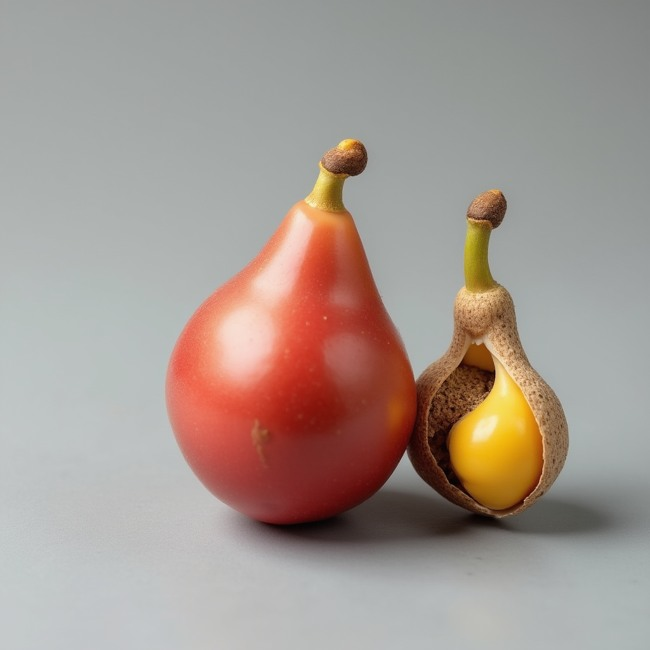
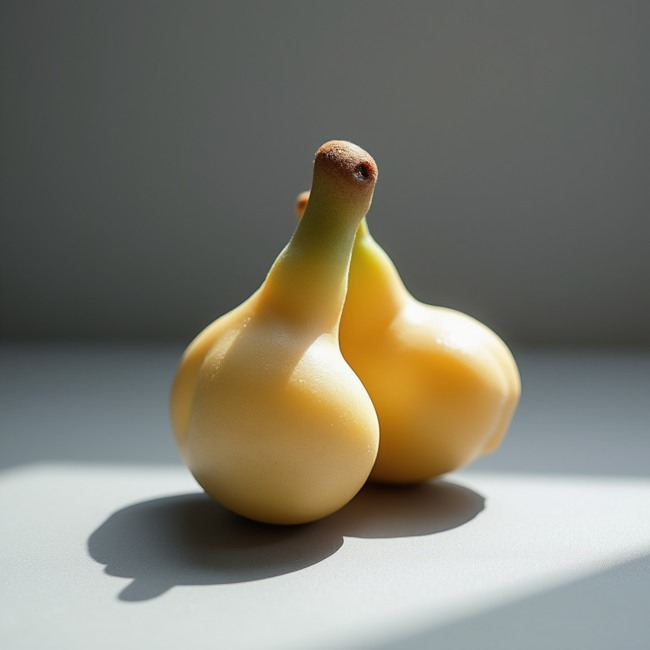
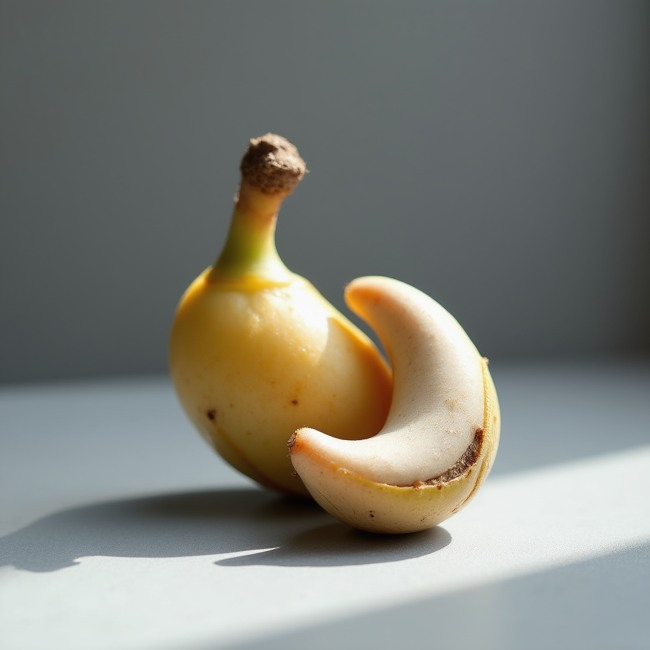
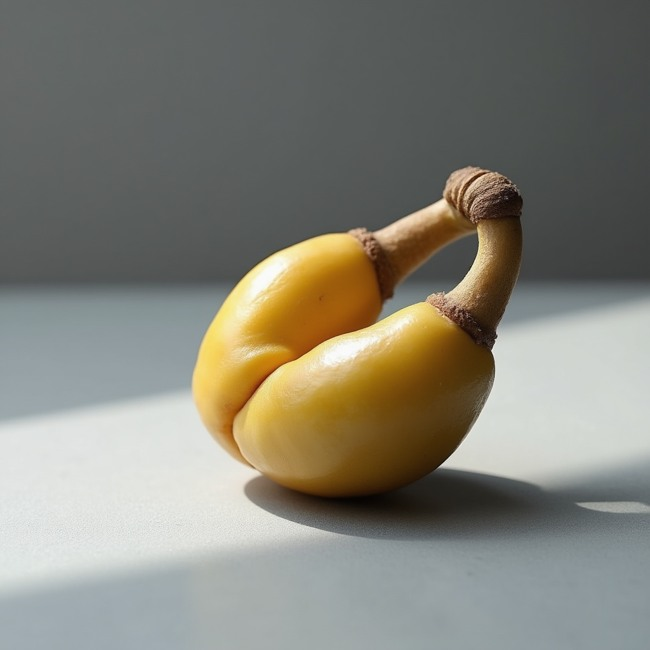
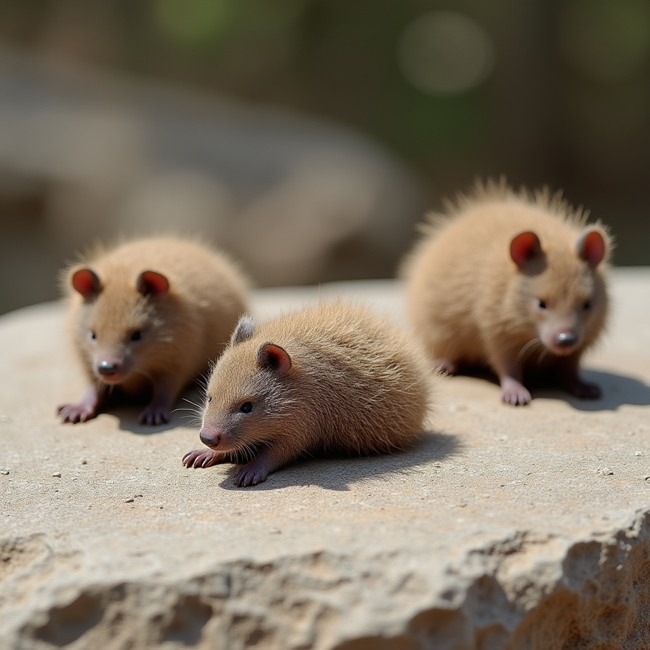
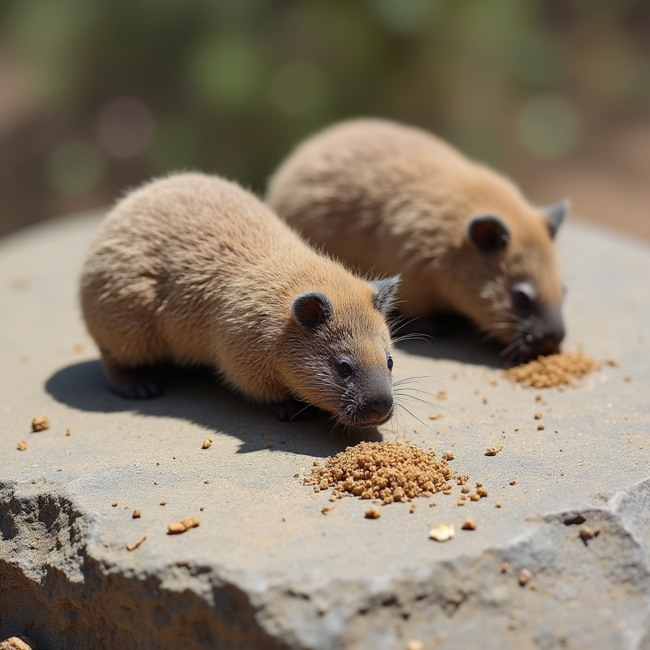
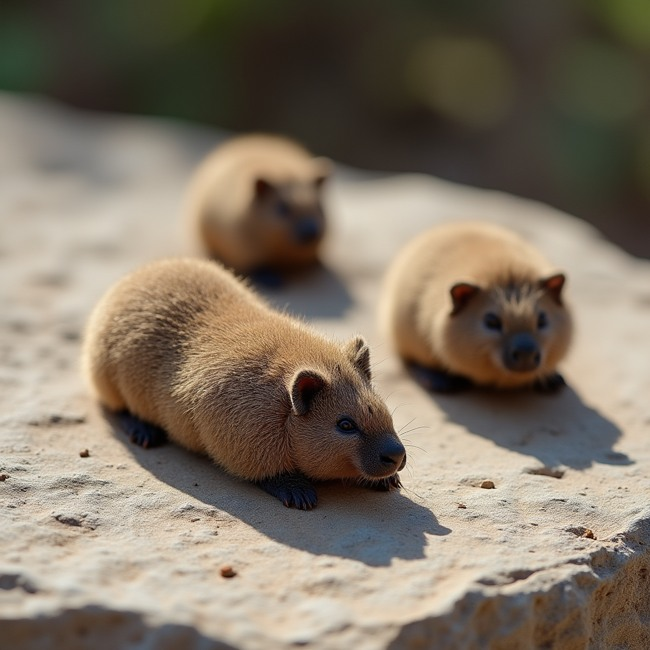
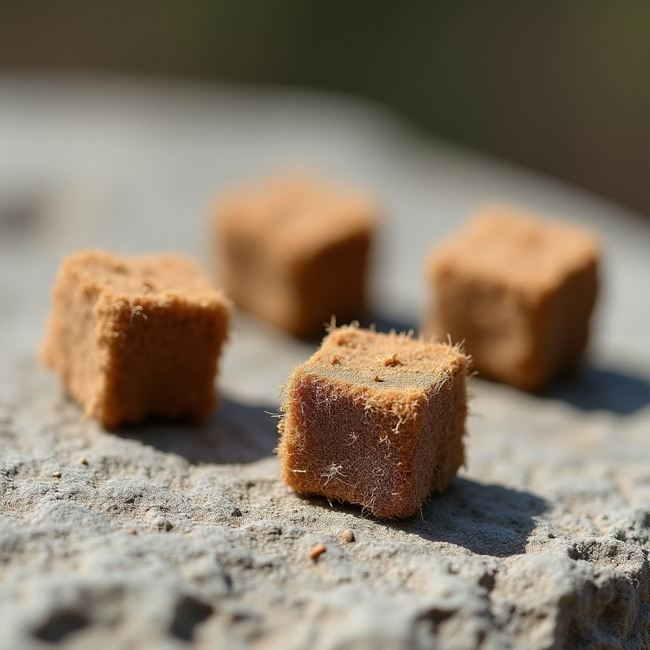
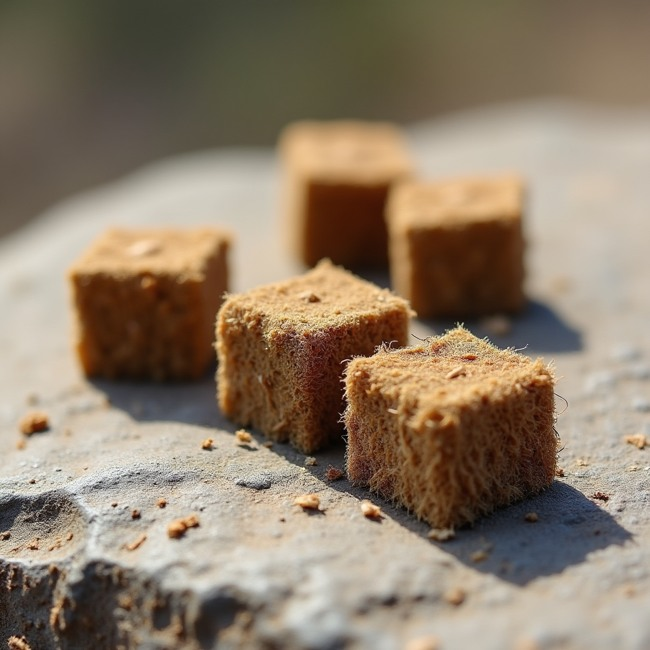
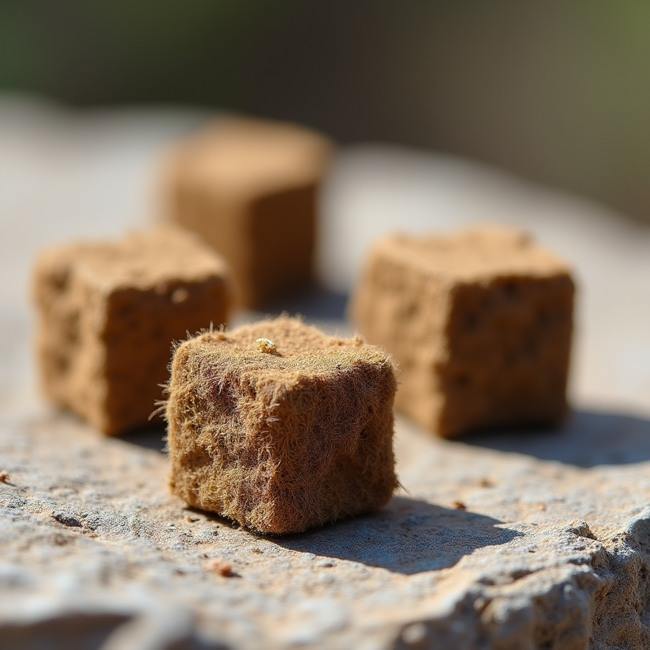
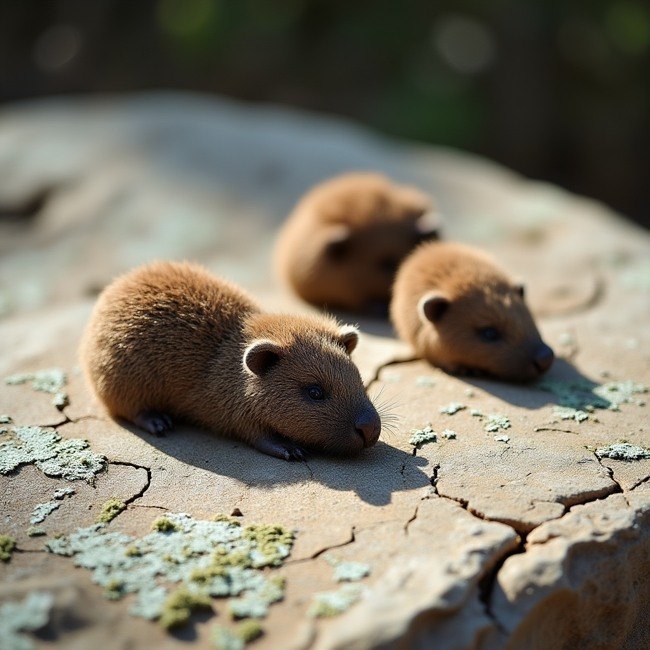
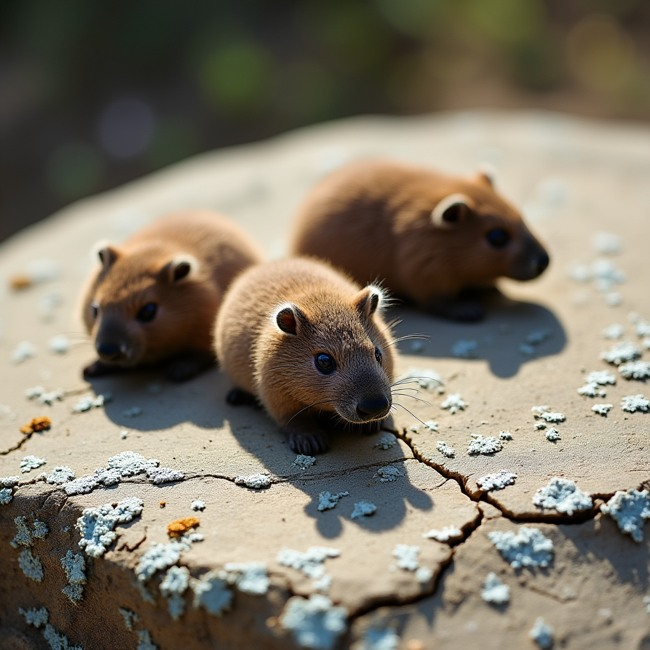
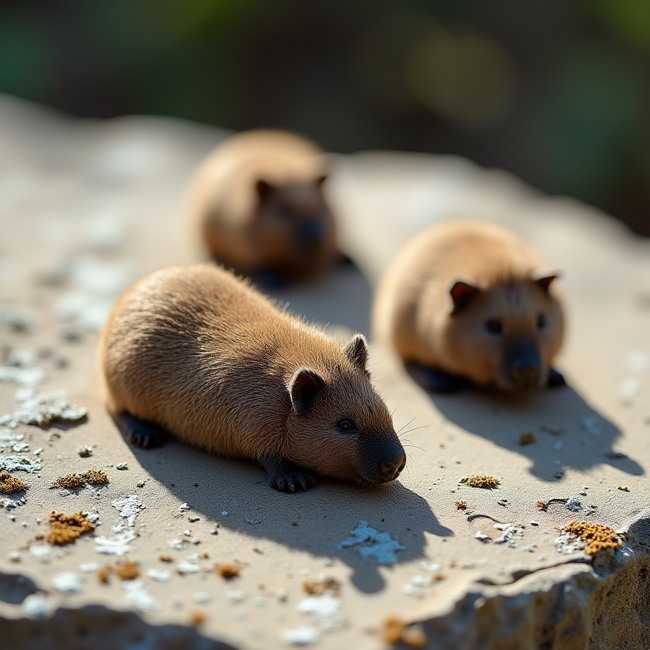

In [3]:
display(HTML(render(color)))

## 推理配置复核

12 张新生成及 4 张原输出复用，检查 512/1024 与 renorm0/1 的影响。此小节为助手看图复核，未匿名；没有把调参数后的输出覆盖原结果。


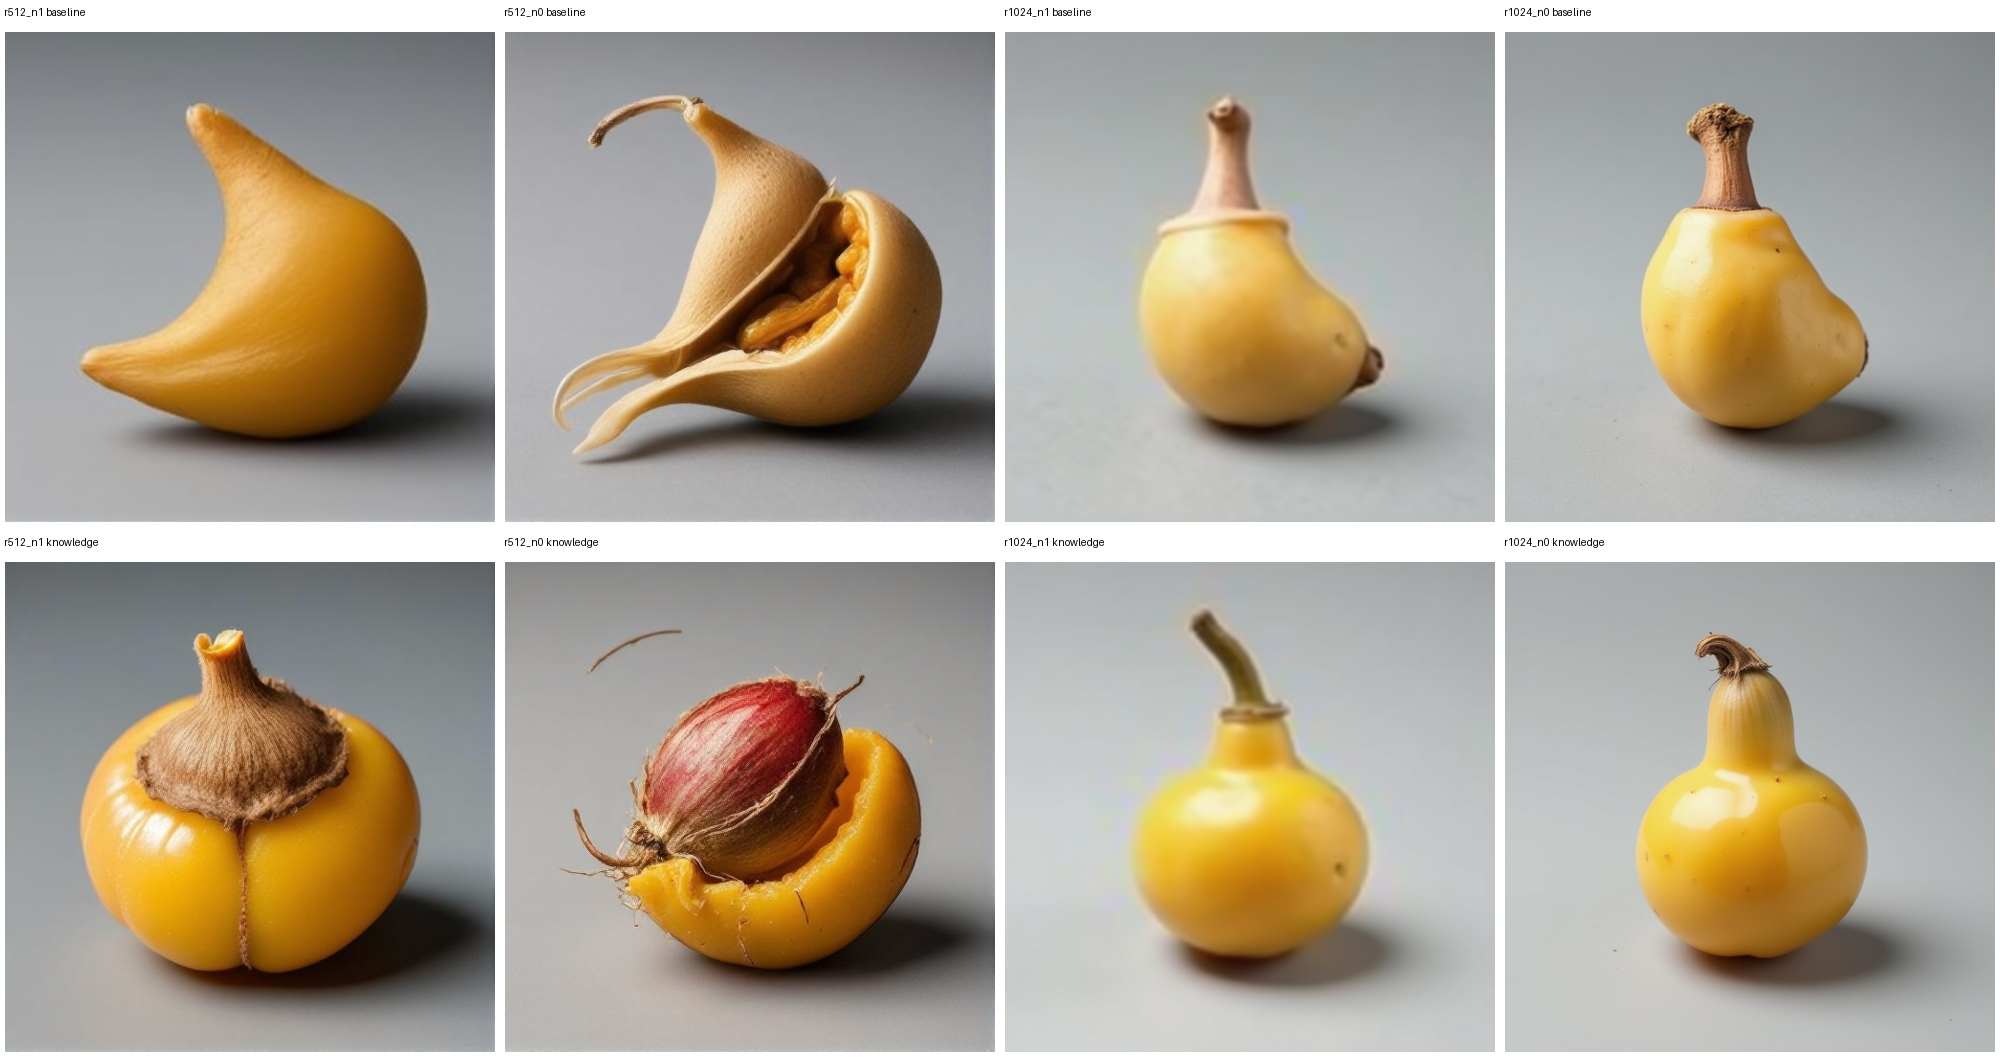
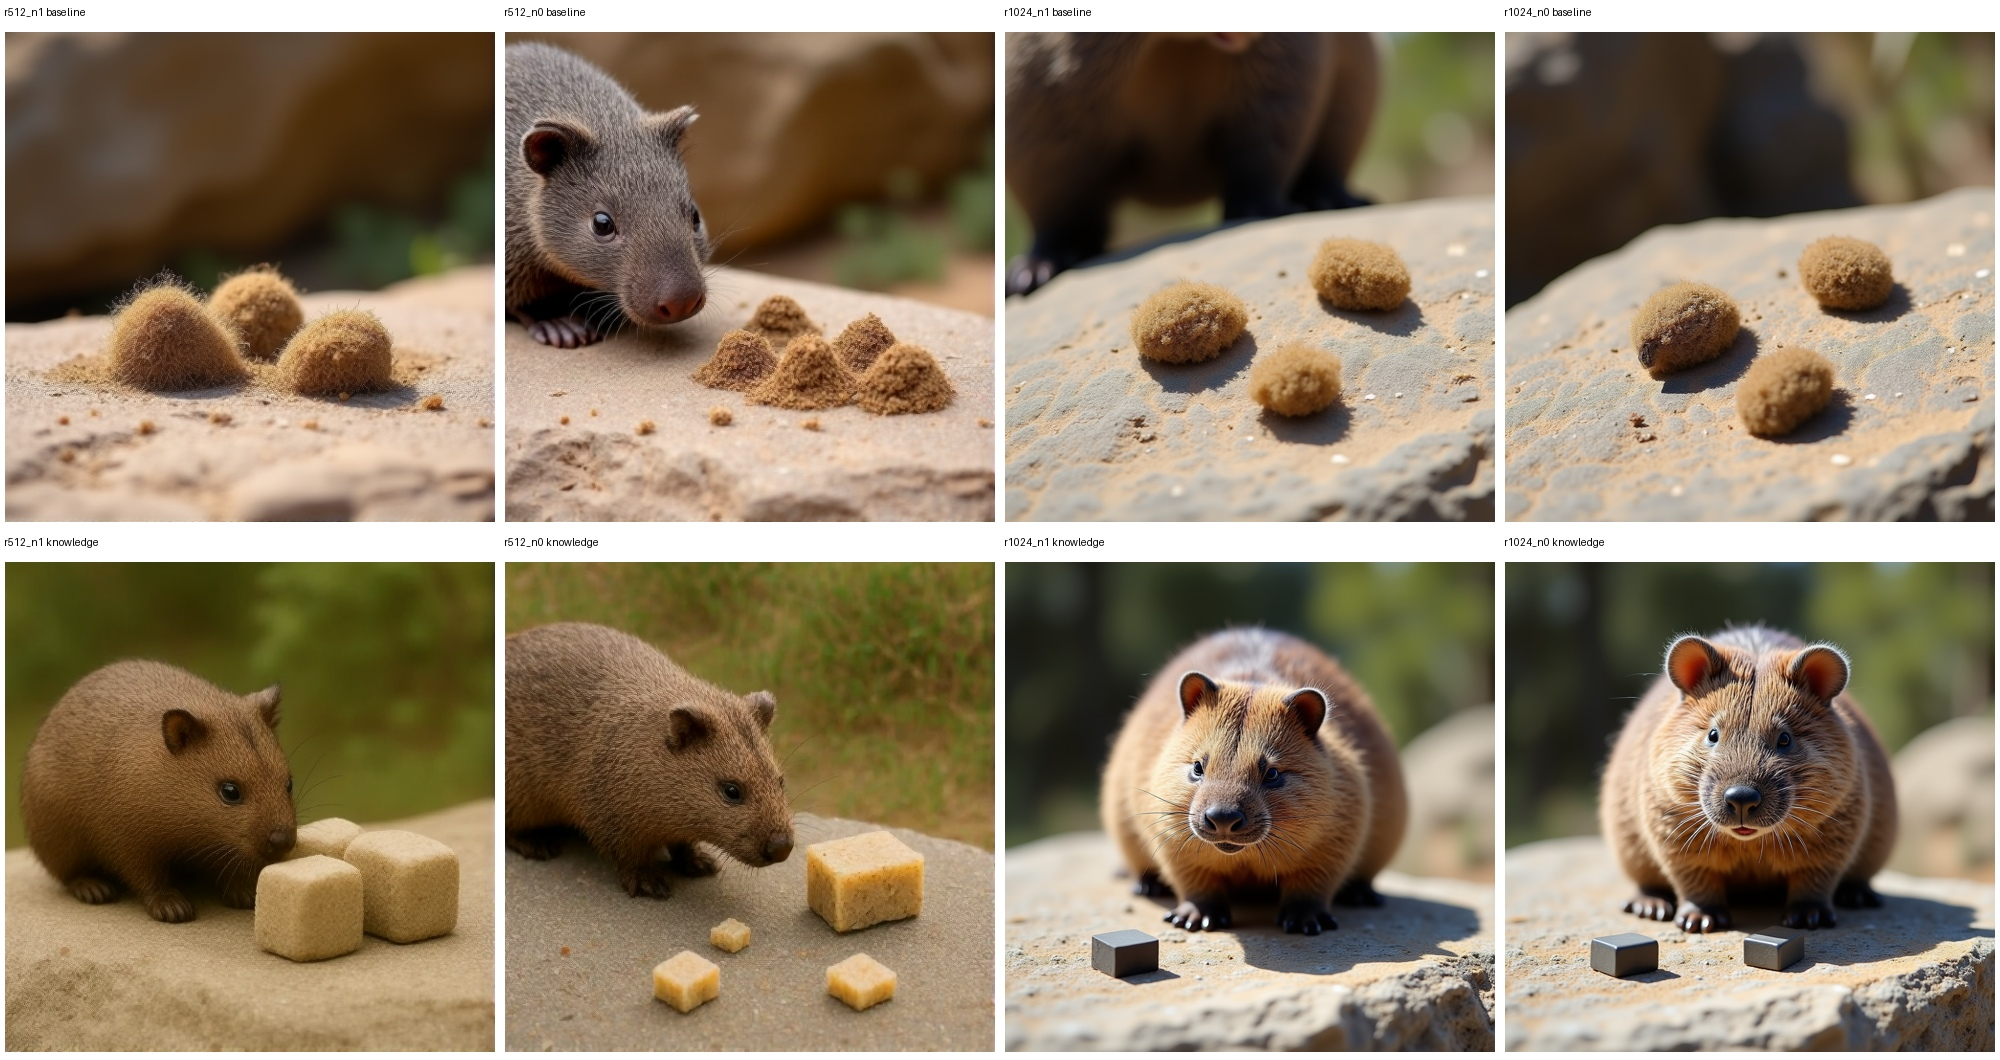

In [4]:
from curation.parameter_probe import render as render_parameters
display(HTML(render_parameters()))